In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nurse-stress-prediction-wearable-sensors/merged_data.csv


you need to installl 
-pip install neurokit2 to your local env. 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#everytime new session starts you need to install in to the consol= pip install neurokit2
import neurokit2 as nk

In [88]:
#normilize features 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
#from imblearn.over_sampling import SMOTE, RamdonOverSampler

In [4]:
!ls /kaggle/input/


nurse-stress-prediction-wearable-sensors


In [5]:
nurse = pd.read_csv("/kaggle/input/nurse-stress-prediction-wearable-sensors/merged_data.csv")

/tmp/ipykernel_47/33907432.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  nurse = pd.read_csv("/kaggle/input/nurse-stress-prediction-wearable-sensors/merged_data.csv")


In [212]:
nurse.shape

(11509051, 10)

In [8]:
nurse.head(5)

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [4]:
nurse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 9 columns):
 #   Column    Dtype  
---  ------    -----  
 0   X         float64
 1   Y         float64
 2   Z         float64
 3   EDA       float64
 4   HR        float64
 5   TEMP      float64
 6   id        object 
 7   datetime  object 
 8   label     float64
dtypes: float64(7), object(2)
memory usage: 790.3+ MB


**Handle missing values**

In [6]:
nurse.isna().sum()

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

In [7]:
empty_string= (nurse==" ").sum()
empty_string

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

In [4]:
whitespace=nurse.map(lambda x: str(x).strip()=="").sum()
whitespace

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

Looks like we don't have any missing values. This is great. 

In [120]:
#quick look in to label
label_counts=nurse['label'].value_counts(normalize=True).sort_index()

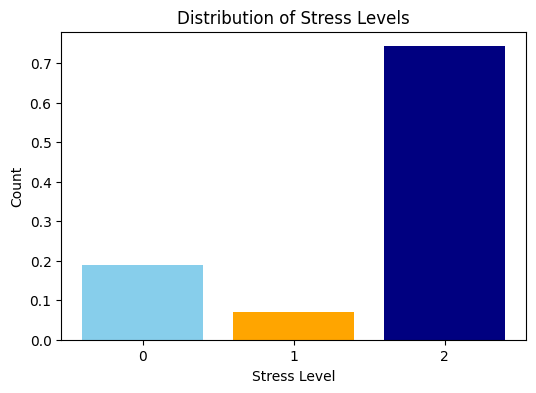

In [122]:
# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values, color=['skyblue','orange','navy'])
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.title('Distribution of Stress Levels')
plt.xticks([0,1,2])  # if your labels are 0,1,2
plt.show()

In [5]:
#quick look into id
nurse["id"].value_counts(normalize=True)

id
E4    0.129278
7A    0.119675
83    0.113886
DF    0.078909
5C    0.075239
6B    0.071730
CE    0.070735
BG    0.052885
6D    0.051382
EG    0.047712
F5    0.046546
94    0.045554
8B    0.036820
15    0.022777
7E    0.022022
83    0.005396
94    0.005370
15    0.004083
Name: proportion, dtype: float64


**Data conversions for datetime, label,id columns and Creating motion column to combine X,Y,Z motions**


In [6]:
nurse["label"]=nurse["label"].astype("category")

In [7]:
#I will convert id to category but for modeling later in ML I will remove it due to data leakage!
nurse["id"]=nurse["id"].astype("category")

In [8]:
nurse['datetime']=pd.to_datetime(nurse['datetime'])

In [9]:
nurse["Motion"]=np.sqrt(nurse["X"]**2+nurse["Y"]**2+nurse["Z"]**2)

In [10]:
nurse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 10 columns):
 #   Column    Dtype         
---  ------    -----         
 0   X         float64       
 1   Y         float64       
 2   Z         float64       
 3   EDA       float64       
 4   HR        float64       
 5   TEMP      float64       
 6   id        category      
 7   datetime  datetime64[ns]
 8   label     category      
 9   Motion    float64       
dtypes: category(2), datetime64[ns](1), float64(7)
memory usage: 724.4 MB


In [11]:
(nurse==0).sum()

X             49794
Y            353055
Z            108740
EDA           31104
HR                0
TEMP              0
id                0
datetime          0
label       2162246
Motion            0
dtype: int64

In [11]:
nurseN=nurse.copy()

In [12]:
nurseN["id"]=nurseN["id"].astype(str).str.strip()

we had 28 unique ids 15,83,94 has 2 seperate id code. bebause some of them had white space. 

In [14]:
nurseN['id'].value_counts()

id
E4    1487871
7A    1377342
83    1372819
DF     908168
5C     865930
6B     825549
CE     814087
BG     608655
6D     591363
94     586096
EG     549124
F5     535706
8B     423763
15     309131
7E     253447
Name: count, dtype: int64

In [13]:
nurseN["id"]=nurseN["id"].astype("category")

-----------------------------------------------------------

In [14]:
newnurse=nurseN[[ "Motion","EDA","HR", "TEMP","id","datetime","label"]]

In [15]:
newnurse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 7 columns):
 #   Column    Dtype         
---  ------    -----         
 0   Motion    float64       
 1   EDA       float64       
 2   HR        float64       
 3   TEMP      float64       
 4   id        category      
 5   datetime  datetime64[ns]
 6   label     category      
dtypes: category(2), datetime64[ns](1), float64(4)
memory usage: 461.0 MB


In [18]:
newnurse.shape

(11509051, 7)

In [19]:
(newnurse==0).sum()

Motion            0
EDA           31104
HR                0
TEMP              0
id                0
datetime          0
label       2162246
dtype: int64

so here we have 31104 rows that has 0 EDA. which means devise was not sensing any signals or not connected. because having 0 as values is not a valid data. these are face 0s. 

I decided to revome these values since I need to handle these properly. it is less than 0.3 % of my data(11million)

In [16]:
EDA0=newnurse[newnurse['EDA']==0]
EDA0.head(5)

,Motion,EDA,HR,TEMP,id,datetime,label
22161,59.472683,0.0,80.18,34.09,15,2020-07-08 13:30:32.500000000,2.0
22162,65.582010,0.0,80.18,34.09,15,2020-07-08 13:30:32.531249920,2.0
22163,64.815122,0.0,80.18,34.09,15,2020-07-08 13:30:32.562500096,2.0
22164,67.349833,0.0,80.18,34.09,15,2020-07-08 13:30:32.593750016,2.0
22165,67.653529,0.0,80.18,34.09,15,2020-07-08 13:30:32.624999936,2.0


In [17]:
#remove EDA=0 rows
newnurse=newnurse[newnurse["EDA"]!=0]

In [21]:
newnurse.shape

(11477947, 7)

In [18]:
(newnurse["EDA"]==0).sum()

0

----------------------------------------------------------

------------------------------------------------------------------------------------------

I will set datetime as index since this dataset is time series dataset, it will be easy to locate rows but For ML I need to extract hour day of the week or time of the dayalso it's memory efficient. from 812mb to 461

let's see if motion resampling with 1m,2m,3m,4m 5m will make a difference

In [19]:
features2=newnurse.copy()
features2=features2.set_index('datetime')

In [20]:
features2.shape

(11477947, 6)

In [21]:
features2.head(5)

,Motion,EDA,HR,TEMP,id,label
datetime,,,,,,
2020-07-08 14:03:00.000000000,62.569961,6.769995,99.43,31.17,15,2.0
2020-07-08 14:03:00.031249920,71.902712,6.769995,99.43,31.17,15,2.0
2020-07-08 14:03:00.062500096,85.264295,6.769995,99.43,31.17,15,2.0
2020-07-08 14:03:00.093750016,88.758098,6.769995,99.43,31.17,15,2.0
2020-07-08 14:03:00.124999936,102.698588,6.769995,99.43,31.17,15,2.0


In [36]:
#if you remove index to regular column --> df=df.reset_index()
#check index--> df.index
#set index-->df=df.set_index('column name')
#dropcolumn--> df=df.drop(columns=['',], errors='ignore')

In [37]:
motion_1m=features2['Motion'].resample("1min").mean()
motion_5m=features2['Motion'].resample("5min").mean()
motion_2m=features2['Motion'].resample("2min").mean()
motion_3m=features2['Motion'].resample("3min").mean()
motion_4m=features2['Motion'].resample("4min").mean()

In [41]:
print(motion_1m.var())
print(motion_2m.var())
print(motion_3m.var())
print(motion_4m.var())
print(motion_5m.var())

31.686792062860167
29.562891835631596
30.04983679569104
29.19892840633281
26.758453911430056


--------------------------

**EDA**

EDA columns adding new ones 

My datetime index is sparse or irrgular across ID's. not every ID has the same dates recored. also some of them recorded 4 days some 10 so on...

here I'm creating tonic column and phasic column for EDA column. counting peaks and total phosic amplitude. 

Because my data doesnt cover only on period of time. each id has it's own datetime for different dates and different gaps. neurokit cannot process because of these irregular or different gaps. 

what I'd do is to create id grouping and day parsing. when working with neurokit. then putting all together. 

In [22]:
#features2=newnurse.copy()
#features2=features2.set_index('datetime')
features2=features2.sort_index()

In [23]:
#split into chunk continious segments. 
def split_continuous_segments(df, max_gap_ms=500):
    times=df.index
    dt=times.to_series().diff().dt.total_seconds()*1000    #milisecond
    segment_id=(dt>max_gap_ms).cumsum()

    segments=[]
    for seg_id in segment_id.unique():
        seg=df[segment_id==seg_id]
        segments.append(seg)
    return segments

def process_segment(segment, sampling_rate=32):

    segment=segment.copy()
    

    if len(segment)< sampling_rate*2:   #must have at leaast 2 second
        segment.loc[:,'EDA_Tonic']=np.nan
        segment.loc[:,'EDA_Phasic']=np.nan
        segment.loc[:,'SCR_Peaks']=np.nan
        return segment
    try:
        signals,info=nk.eda_process(segment['EDA'], sampling_rate=sampling_rate)
        segment.loc[:,'EDA_Tonic']=signals['EDA_Tonic'].values
        segment.loc[:,'EDA_Phasic']=signals['EDA_Phasic'].values
        segment.loc[:,'SCR_Peaks']=signals['SCR_Peaks'].values
    except:
        segment.loc[:,'EDA_Tonic']=np.nan
        segment.loc[:,'EDA_Phasic']=np.nan
        segment.loc[:,'SCR_Peaks']=np.nan
    return segment

processed_segments=[]

for id_values, df_id in features2.groupby("id", observed=False ):
    #print (f"ID {id_values}")

    segments=split_continuous_segments(df_id)

    for seg in segments:
        seg_processed=process_segment(seg, sampling_rate=32)
        processed_segments.append(seg_processed)

#Recombine them all
eda_processed=pd.concat(processed_segments).sort_index()

eda_processed = eda_processed[~eda_processed.index.duplicated(keep='first')]

eda_features = eda_processed[['EDA_Tonic', 'EDA_Phasic', 'SCR_Peaks']]
features2 = features2.join(eda_features, how='left')


#print(features2.shape)
#print(features2[['EDA_Tonic','EDA_Phasic', 'SCR_Peaks']].head(10))

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.

In [23]:
features2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11477947 entries, 2020-04-14 22:31:00 to 2020-12-13 08:01:00
Data columns (total 9 columns):
 #   Column      Dtype   
---  ------      -----   
 0   Motion      float64 
 1   EDA         float64 
 2   HR          float64 
 3   TEMP        float64 
 4   id          category
 5   label       category
 6   EDA_Tonic   float64 
 7   EDA_Phasic  float64 
 8   SCR_Peaks   float64 
dtypes: category(2), float64(7)
memory usage: 722.5 MB


In [24]:
features2.isna().sum()

Motion           0
EDA              0
HR               0
TEMP             0
id               0
label            0
EDA_Tonic     3333
EDA_Phasic    3333
SCR_Peaks     3333
dtype: int64

I usually keep NaNs for temporal physiological data and let the model or resampling handle them.
for this I'm going to short by id and date so my data is organized and when I'm filling the NAN's it will look into same id's information to fill in. 
I will create new dataset for easy return to original. 

In [25]:
featuresO=features2.copy()

In [26]:
featuresO=featuresO.sort_values(by=['id', 'datetime'])

This dataset is sort by id. not group by id yet. 

In [27]:

def fill_eda(group):
    group[['EDA_Tonic','EDA_Phasic','SCR_Peaks']]=group[['EDA_Tonic','EDA_Phasic','SCR_Peaks']].interpolate(method='linear')
    group[['EDA_Tonic','EDA_Phasic','SCR_Peaks']]=group[['EDA_Tonic','EDA_Phasic','SCR_Peaks']].ffill().bfill()
    return group
featuresO=featuresO.groupby('id', group_keys=False).apply(fill_eda)

/tmp/ipykernel_47/2541030491.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  featuresO=featuresO.groupby('id', group_keys=False).apply(fill_eda)
/tmp/ipykernel_47/2541030491.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  featuresO=featuresO.groupby('id', group_keys=False).apply(fill_eda)


In [28]:
featuresO.isna().sum()

Motion        0
EDA           0
HR            0
TEMP          0
id            0
label         0
EDA_Tonic     0
EDA_Phasic    0
SCR_Peaks     0
dtype: int64

In [29]:
featuresO.shape

(11477947, 9)

In [48]:
featuresO.value_counts('label')

label
2.0    8527263
0.0    2158734
1.0     791950
Name: count, dtype: int64

In [122]:
featuresO.value_counts('id')

id
E4    1487007
7A    1374238
83    1372507
DF     908152
5C     853922
6B     819909
CE     813855
BG     607223
6D     591339
94     583144
EG     548580
F5     533962
8B     423747
15     306915
7E     253447
Name: count, dtype: int64

-------------------------

Create date and hour columns ad hour sin/cos columns 

In [29]:
featuresO['date']=featuresO.index.date
featuresO['hour']=featuresO.index.hour
featuresO['day_of_week']=featuresO.index.dayofweek

In [30]:
featuresO['hour_sin']=np.sin(2*np.pi*featuresO['hour']/24)
featuresO['hour_cos']=np.cos(2*np.pi*featuresO['hour']/24)

In [31]:
featuresO['day_sin']=np.sin(2*np.pi*featuresO['day_of_week']/7)
featuresO['day_cos']=np.cos(2*np.pi*featuresO['day_of_week']/7)

In [32]:
featuresO['date']=pd.to_datetime(featuresO['date'])

In [33]:
featuresO.head(1)

,Motion,EDA,HR,TEMP,id,label,EDA_Tonic,EDA_Phasic,SCR_Peaks,date,hour,day_of_week,hour_sin,hour_cos,day_sin,day_cos
datetime,,,,,,,,,,,,,,,,
2020-07-08 13:09:00,56.044625,2.567307,77.27,32.65,15,2.0,2.721237,-0.154703,0.0,2020-07-08,13,2,-0.258819,-0.965926,0.974928,-0.222521


In [35]:
featuresO.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11477947 entries, 2020-07-08 13:09:00 to 2020-07-23 17:29:00
Data columns (total 16 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Motion       float64       
 1   EDA          float64       
 2   HR           float64       
 3   TEMP         float64       
 4   id           category      
 5   label        category      
 6   EDA_Tonic    float64       
 7   EDA_Phasic   float64       
 8   SCR_Peaks    float64       
 9   date         datetime64[ns]
 10  hour         int32         
 11  day_of_week  int32         
 12  hour_sin     float64       
 13  hour_cos     float64       
 14  day_sin      float64       
 15  day_cos      float64       
dtypes: category(2), datetime64[ns](1), float64(11), int32(2)
memory usage: 1.2 GB


HR add new columns EDA 

I did time interval for HR. like every 30 second what is mean.diff.std 

In [34]:
#make datetime a column again       before doing HR new columns. we need to reset_index() because it wont work for rolling 
featuresO=featuresO.reset_index(drop=False)

In [35]:
featuresO=featuresO.sort_values(['id','datetime'])

In [36]:

featuresO['HR_diff']=featuresO.groupby('id')['HR'].diff()


/tmp/ipykernel_47/2456648728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  featuresO['HR_diff']=featuresO.groupby('id')['HR'].diff()


In [37]:
def hr_std(df):
    return df.rolling('30s', on='datetime')['HR'].std()
    
featuresO['HR_std']=featuresO.groupby('id', group_keys=False).apply(hr_std)

def hr_mean(df):
    return df.rolling('30s', on='datetime')['HR'].mean()

featuresO['HR_mean']=featuresO.groupby('id',group_keys=False).apply(hr_mean)


/tmp/ipykernel_47/4257656042.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  featuresO['HR_std']=featuresO.groupby('id', group_keys=False).apply(hr_std)
/tmp/ipykernel_47/4257656042.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  featuresO['HR_std']=featuresO.groupby('id', group_keys=False).apply(hr_std)
/tmp/ipykernel_47/4257656042.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior

In [45]:
#featuresO=featuresO.drop(columns=['HR_std','HR_diff','HR_mean','index'])
#featuresO=featuresO.drop(columns=['HR_diff'])

I'm ffilling emty or 0 ones 

In [38]:
featuresO[['HR_std','HR_diff']]= featuresO.groupby('id')[['HR_diff','HR_std']].ffill()

/tmp/ipykernel_47/1142102607.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  featuresO[['HR_std','HR_diff']]= featuresO.groupby('id')[['HR_diff','HR_std']].ffill()


Same HR thing for motion. std ad mean only. ffilled 0 rows. 

In [39]:
def motion_std(df):
    return df.rolling('30s', on='datetime')['Motion'].std()
featuresO[ 'Motion_std']=featuresO.groupby('id', group_keys=False).apply(motion_std)
def motion_mean(df):
    return df.rolling('30s', on='datetime')['Motion'].mean()
featuresO[ 'Motion_mean']=featuresO.groupby('id', group_keys=False).apply(motion_mean)

/tmp/ipykernel_47/61063937.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  featuresO[ 'Motion_std']=featuresO.groupby('id', group_keys=False).apply(motion_std)
/tmp/ipykernel_47/61063937.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  featuresO[ 'Motion_std']=featuresO.groupby('id', group_keys=False).apply(motion_std)
/tmp/ipykernel_47/61063937.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

In [40]:
featuresO[['Motion_std']]= featuresO.groupby('id')[['Motion_std']].ffill()

/tmp/ipykernel_47/3613442735.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  featuresO[['Motion_std']]= featuresO.groupby('id')[['Motion_std']].ffill()


In [41]:
featuresO.isna().sum()

datetime        0
Motion          0
EDA             0
HR              0
TEMP            0
id              0
label           0
EDA_Tonic       0
EDA_Phasic      0
SCR_Peaks       0
date            0
hour            0
day_of_week     0
hour_sin        0
hour_cos        0
day_sin         0
day_cos         0
HR_diff        15
HR_std         15
HR_mean         0
Motion_std     15
Motion_mean     0
dtype: int64

**YOU NEEED TO FILL UP THESE 15 NAN THAT HR_STD AND hr_DIFF and Motion _Std HAVE WHEN YOU NEED TO MODEL YOU DATASET. JUST THESE. BUT FOR NOW, LEAVE THEM ALONE**

In [67]:

#featuresO.isna().sum()
#featuresO['HR_diff']=featuresO['HR_diff'].fillna(0)  
#featuresO['HR_std']=featuresO['HR_std'].fillna(0)  
#featuresO['Motion_std']=featuresO['Motion_std'].fillna(0)  

In [42]:
featuresO.head(1)       


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,datetime,Motion,EDA,HR,TEMP,id,label,EDA_Tonic,EDA_Phasic,SCR_Peaks,...,day_of_week,hour_sin,hour_cos,day_sin,day_cos,HR_diff,HR_std,HR_mean,Motion_std,Motion_mean
0,2020-07-08 13:09:00,56.044625,2.567307,77.27,32.65,15,2.0,2.721237,-0.154703,0.0,...,2,-0.258819,-0.965926,0.974928,-0.222521,NaN,NaN,77.27,NaN,56.044625


when reloading this dataset from csv please convert these again. 

features_new['id'] = features_new['id'].astype('category')
features_new['label'] = features_new['label'].astype('category')

CSV handles NaNs fine — they’ll appear as empty cells. so we need to see these cells 15 of them deal with them

datetime= CSV may truncate to milliseconds. it says okay for resamplng for 30s or 1m but . dont know. 

In [43]:

#create new dataset before resampling
featuresR=featuresO.copy()

In [44]:
featuresR=featuresR.set_index('datetime')

In [45]:
featuresR.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11477947 entries, 2020-07-08 13:09:00 to 2020-07-23 17:29:00
Data columns (total 21 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Motion       float64       
 1   EDA          float64       
 2   HR           float64       
 3   TEMP         float64       
 4   id           category      
 5   label        category      
 6   EDA_Tonic    float64       
 7   EDA_Phasic   float64       
 8   SCR_Peaks    float64       
 9   date         datetime64[ns]
 10  hour         int32         
 11  day_of_week  int32         
 12  hour_sin     float64       
 13  hour_cos     float64       
 14  day_sin      float64       
 15  day_cos      float64       
 16  HR_diff      float64       
 17  HR_std       float64       
 18  HR_mean      float64       
 19  Motion_std   float64       
 20  Motion_mean  float64       
dtypes: category(2), datetime64[ns](1), float64(16), int32(2)
memory usage: 1.6 GB


-----------------------------------

30's --> high resolution captures fine grained changes. large dataset slow to train
1m--> good balance, smooths out noise but preserves dynamics
5m--> very small dataset, loses short term patterns, fast to train 

RESAMPLING

In [46]:
def safe_mode(x):
    if x.empty:
        return np.nan
    m=x.mode()
    if m.empty:
        return np.nan
    return m.iloc[0]

num_cols=['Motion','Motion_std','Motion_mean','EDA','EDA_Tonic','EDA_Phasic','HR','HR_std','HR_mean','HR_diff','TEMP','hour_sin','hour_cos','day_sin','day_cos']
cat_cols=['label']
scr_col=['SCR_Peaks']

features1R=featuresR.groupby('id').resample('1min').agg({
    **{col: 'mean' for col in num_cols},
    **{col: safe_mode for col in cat_cols},
    **{col: 'sum' for col in scr_col},
    'date': 'first'
    
})
features5R=featuresR.groupby('id').resample('5min').agg({
    **{col: 'mean' for col in num_cols},
    **{col: safe_mode for col in cat_cols},
    **{col: 'sum' for col in scr_col},
    'date': 'first'
})
features30R=featuresR.groupby('id').resample('30s').agg({
    **{col: 'mean' for col in num_cols},
    **{col: safe_mode for col in cat_cols},
    **{col: 'sum' for col in scr_col},
    'date': 'first'
    
})

/tmp/ipykernel_47/237884350.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  features1R=featuresR.groupby('id').resample('1min').agg({
/tmp/ipykernel_47/237884350.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  features5R=featuresR.groupby('id').resample('5min').agg({
/tmp/ipykernel_47/237884350.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  features30R=featuresR.groupby('id').resample('30s').agg({


I checked every id if they are missing any values after resampling (1 min) but they don't. Here below when we look into whole data if any data is NAN,it has 925198 rows. These happened because when panda resamples my timeseries dataset, it get min and max data then resamples every minute between those dates. The Best aproach is to remove them so we have our data without NAN rows.

In [47]:
features30R.isna().sum()

Motion         1574892
Motion_std     1574892
Motion_mean    1574892
EDA            1574892
EDA_Tonic      1574892
EDA_Phasic     1574892
HR             1574892
HR_std         1574892
HR_mean        1574892
HR_diff        1574892
TEMP           1574892
hour_sin       1574892
hour_cos       1574892
day_sin        1574892
day_cos        1574892
label          1574892
SCR_Peaks            0
date           1574892
dtype: int64

In [48]:
features30R.head(5)

Motion  Motion_std  Motion_mean       EDA  \
id datetime                                                            
15 2020-07-08 13:09:00  66.134039   10.935840    66.325736  3.088903   
   2020-07-08 13:09:30  64.258897    6.271229    64.956438  1.522436   
   2020-07-08 13:10:00  64.609371    5.741256    64.625065  3.400481   
   2020-07-08 13:10:30  64.915591    7.668255    64.892687  3.897341   
   2020-07-08 13:11:00  64.896254    6.718946    64.803544  4.173519   

                        EDA_Tonic  EDA_Phasic         HR    HR_std    HR_mean  \
id datetime                                                                     
15 2020-07-08 13:09:00   3.088327    0.000890  74.364667 -0.005443  75.848496   
   2020-07-08 13:09:30   1.565033    0.028335  72.243611 -0.003067  73.006016   
   2020-07-08 13:10:00   3.380872    0.019598  68.674667 -0.000260  70.092268   
   2020-07-08 13:10:30   3.882470    0.014823  69.839000  0.004115  69.084301   
   2020-07-08 13:11:00   4.144828    0.028575  75.374333  0.003677  72.695872   

                         HR_diff       TEMP  hour_sin  hour_cos   day_sin  \
id datetime                                                                 
15 2020-07-08 13:09:00  0.909060  32.407000 -0.258819 -0.965926  0.974928   
   2020-07-08 13:09:30  0.939526  32.471481 -0.258819 -0.965926  0.974928   
   2020-07-08 13:10:00  1.493157  32.409333 -0.258819 -0.965926  0.974928   
   2020-07-08 13:10:30  0.407095  32.733667 -0.258819 -0.965926  0.974928   
   2020-07-08 13:11:00  1.827178  33.053000 -0.258819 -0.965926  0.974928   

                         day_cos label  SCR_Peaks       date  
id datetime                                                   
15 2020-07-08 13:09:00 -0.222521   2.0       14.0 2020-07-08  
   2020-07-08 13:09:30 -0.222521   2.0       15.0 2020-07-08  
   2020-07-08 13:10:00 -0.222521   2.0        8.0 2020-07-08  
   2020-07-08 13:10:30 -0.222521   2.0       11.0 2020-07-08  
   2020-07-08 13:11:00 -0.222521   2.0       10.0 2020-07-08

In [91]:
#df30=features30R.copy()
#df5=features5R.copy()
#df1=features1R.copy()

In [92]:
#num_cols=['Motion','EDA','EDA_Tonic','EDA_Phasic','HR','TEMP']
#df1=df1.dropna(subset=num_cols, how='all')
#df5=df5.dropna(subset=num_cols,how='all')
#df30=df30.dropna(subset=num_cols,how='all')

In [116]:
#df5.to_csv('df5.csv', index=False)


In [98]:
# load resampling datasets. 
#df30 = pd.read_csv('df30.csv')  #, parse_dates=['datetime'])--> what is this 

(6151, 18)

1m before removing NAN(793499, 8) and has  787348 NAN--> 6.000

5m before removing NAN (158708, 8) and has 157320 NAN --> 1.000

30s before removin NAN (1586983, 8) and has 1574892 NAN     --> 12.000

In [50]:
num_cols=['Motion','EDA','EDA_Tonic','EDA_Phasic','HR','TEMP']
features1R=features1R.dropna(subset=num_cols, how='all')
features5R=features5R.dropna(subset=num_cols,how='all')
features30R=features30R.dropna(subset=num_cols,how='all')

ML NOTE FOR IMBALaNCE:
your data is imbalanced and has small dataset after resampling. so you need to consider resmapling, weight loss, oversampling minority class... 

small dataset:always use CV (kfold or stratified) for performance est.

Since your dataset has 2 index now from grouping, you are keeping datetime as index and removing id from index. 

In [51]:
#features30R.info()
features30R=features30R.reset_index(level='id')

**VIZUALIZATION**
FOCUS ON DISTRIBUTION, TREND, CORRELATION

hour sin,cos are more for ML so that model can think time as circle like a clock


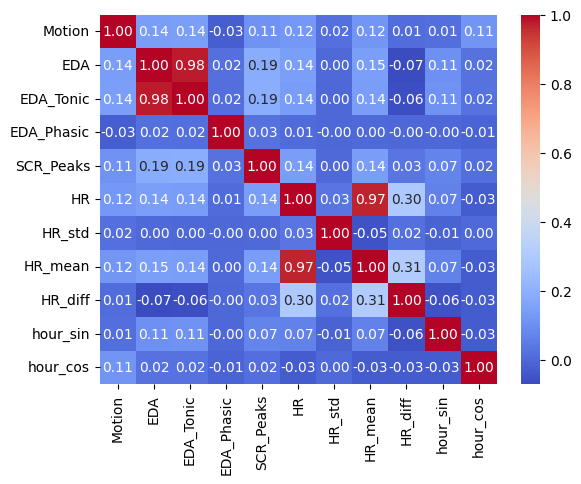

In [203]:
corr_cols=['Motion','EDA','EDA_Tonic','EDA_Phasic','SCR_Peaks','HR','HR_std','HR_mean','HR_diff','hour_sin','hour_cos']
sns.heatmap(features30R[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


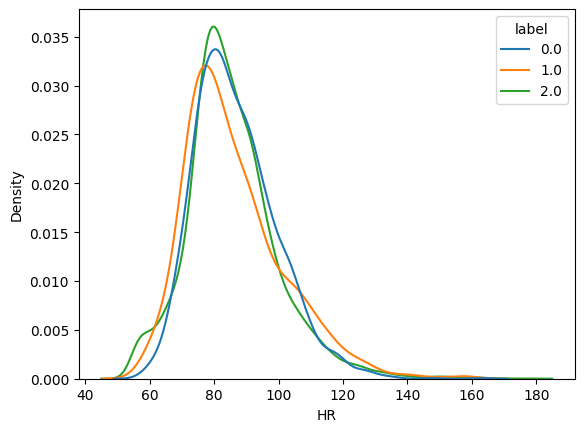

In [125]:
sns.kdeplot(data=features30R, x='HR', hue='label', common_norm=False)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


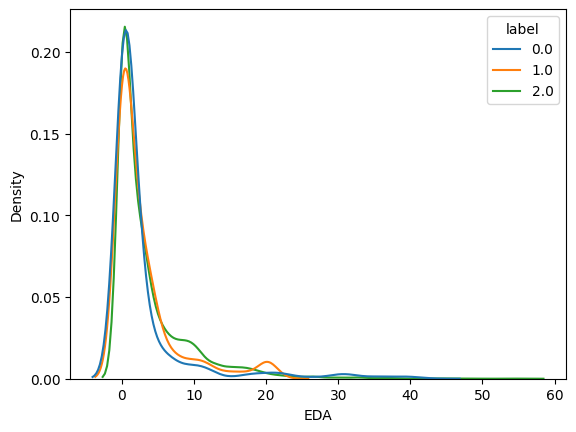

In [127]:
sns.kdeplot(data=features30R, x='EDA', hue='label', common_norm=False)
plt.show()

In [52]:
#add these before changing  datetime index to column , these are the only ones got lost. 
features30R['hour']=features30R.index.hour
features30R['day_of_week']=features30R.index.dayofweek

In [53]:
#this dataset datetime is index. datetime column is datetime but it still converts it I dont get why
features30R=features30R.reset_index()



In [56]:
frequent_ids = ['6B','6D','7E','F5','EG','8B','DF']      # daily or every 2 days
semi_frequent_ids = ['5C','7A','E4']       # twice a month
rare_ids = ['15','83','94','BG','CE']                # every 4-7 days

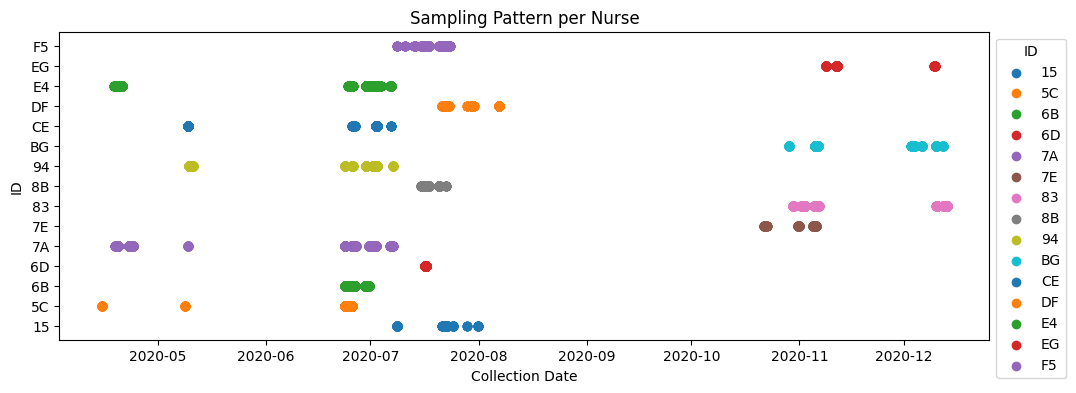

In [132]:
id_list = features30R['id'].unique()
plt.figure(figsize=(12,4))
for uid in id_list:
    df_id = features30R[features30R['id'] == uid]
    plt.scatter(df_id['datetime'], [uid]*len(df_id), label=uid)
plt.ylabel('ID')
plt.xlabel('Collection Date')
plt.title('Sampling Pattern per Nurse')
plt.legend(title='ID', bbox_to_anchor=(1, 1), loc='upper left')

plt.show()

In [61]:
features30R.head(2)

,datetime,id,Motion,Motion_std,Motion_mean,EDA,EDA_Tonic,EDA_Phasic,HR,HR_std,...,TEMP,hour_sin,hour_cos,day_sin,day_cos,label,SCR_Peaks,date,hour,day_of_week
0,2020-07-08 13:09:00,15,66.134039,10.935840,66.325736,3.088903,3.088327,0.000890,74.364667,-0.005443,...,32.407000,-0.258819,-0.965926,0.974928,-0.222521,2.0,14.0,2020-07-08,13,2
1,2020-07-08 13:09:30,15,64.258897,6.271229,64.956438,1.522436,1.565033,0.028335,72.243611,-0.003067,...,32.471481,-0.258819,-0.965926,0.974928,-0.222521,2.0,15.0,2020-07-08,13,2


In [ ]:
#this is not body temp it's skin temp
temp_unique=[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
#then threshold would be 70 I also have motion bigger then 80 
benim_motion=[60,80]
#HR 100 and above consered high HR
benim_HR='100'  

In [54]:

features30R.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12091 entries, 0 to 12090
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     12091 non-null  datetime64[ns]
 1   id           12091 non-null  category      
 2   Motion       12091 non-null  float64       
 3   Motion_std   12091 non-null  float64       
 4   Motion_mean  12091 non-null  float64       
 5   EDA          12091 non-null  float64       
 6   EDA_Tonic    12091 non-null  float64       
 7   EDA_Phasic   12091 non-null  float64       
 8   HR           12091 non-null  float64       
 9   HR_std       12091 non-null  float64       
 10  HR_mean      12091 non-null  float64       
 11  HR_diff      12091 non-null  float64       
 12  TEMP         12091 non-null  float64       
 13  hour_sin     12091 non-null  float64       
 14  hour_cos     12091 non-null  float64       
 15  day_sin      12091 non-null  float64       
 16  day_

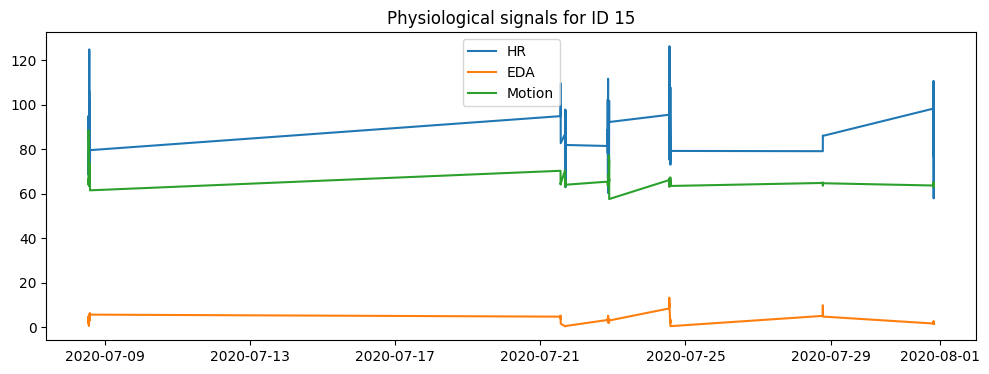

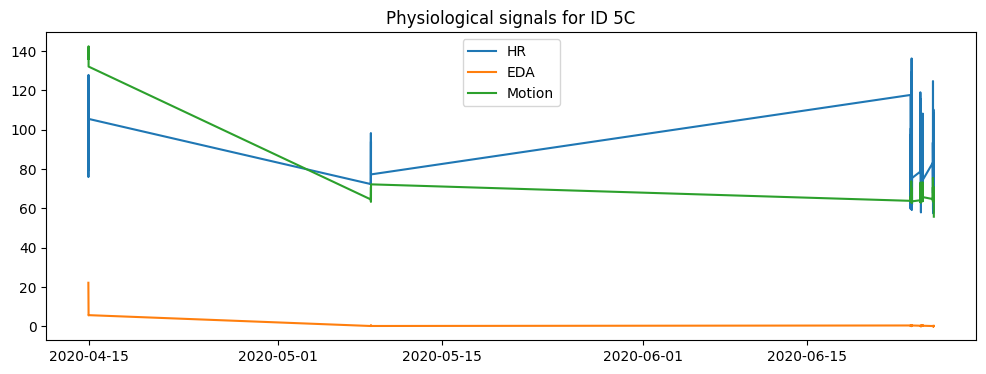

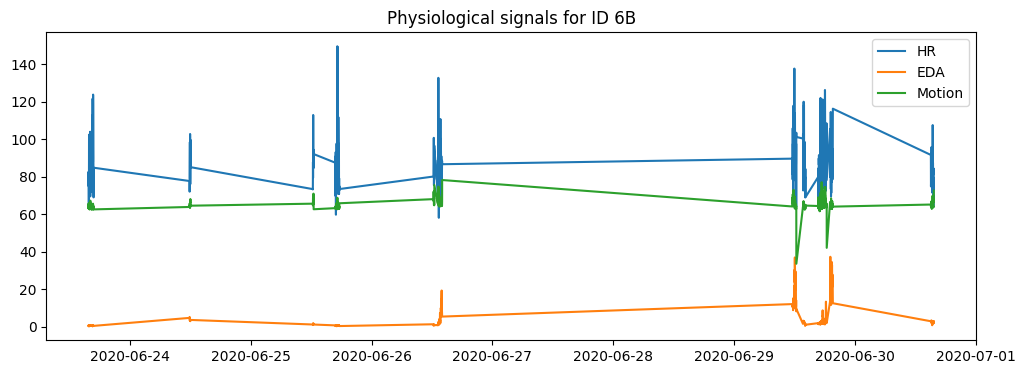

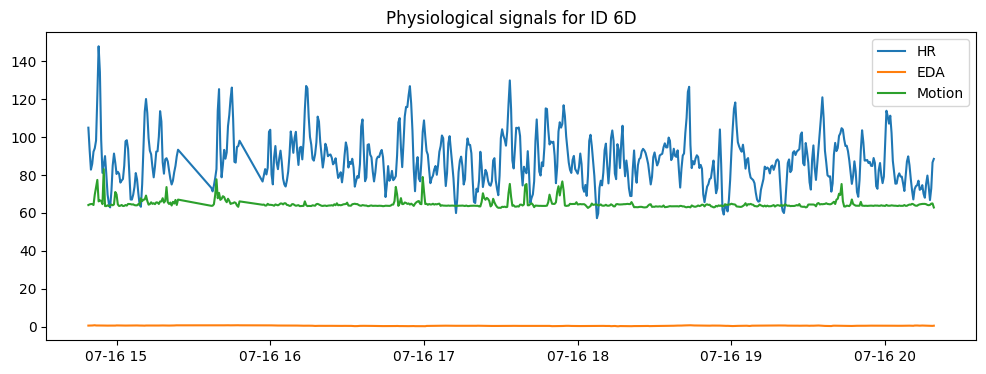

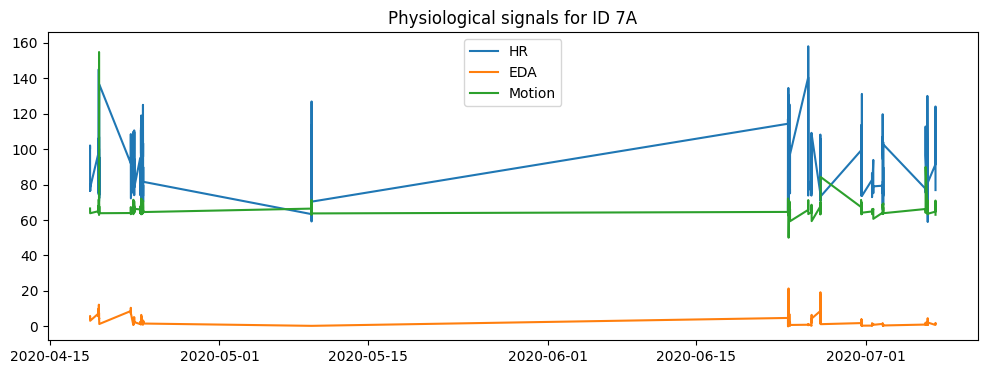

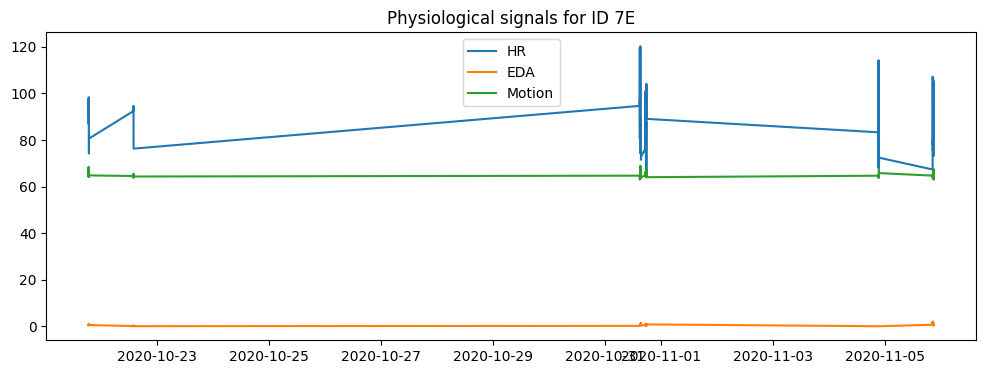

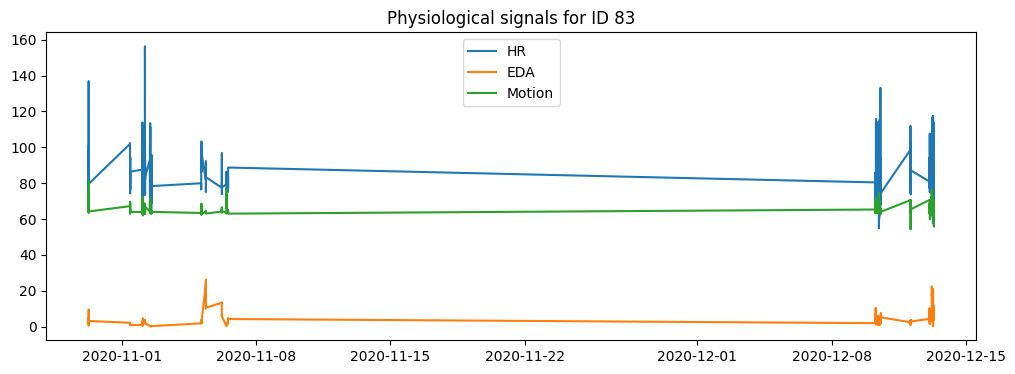

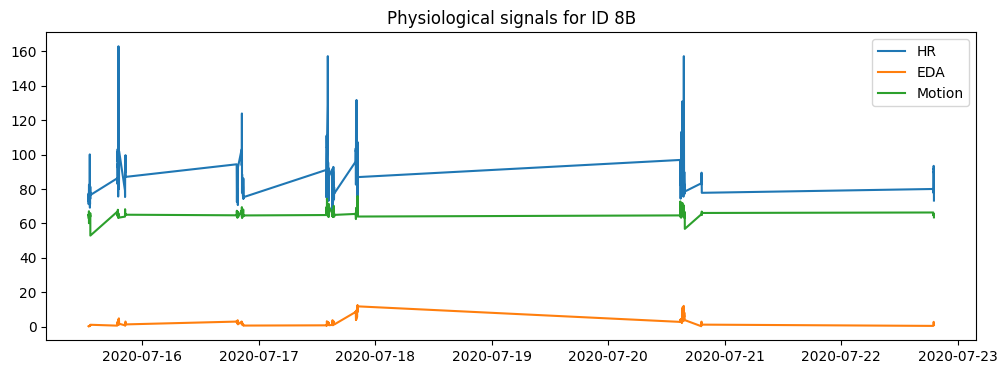

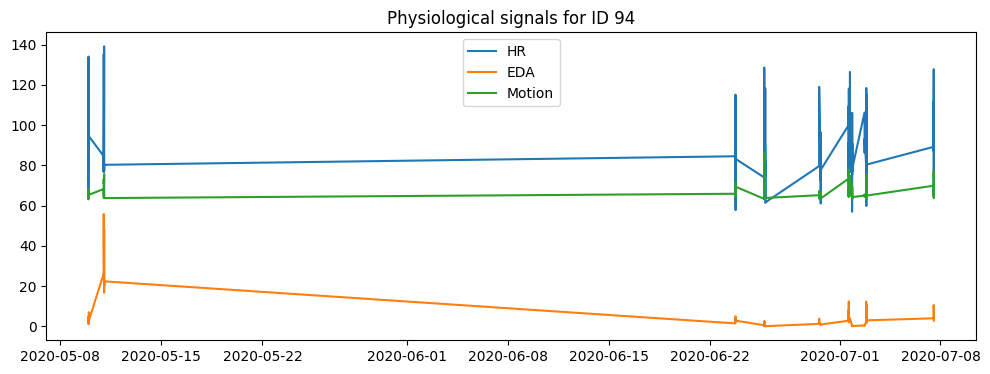

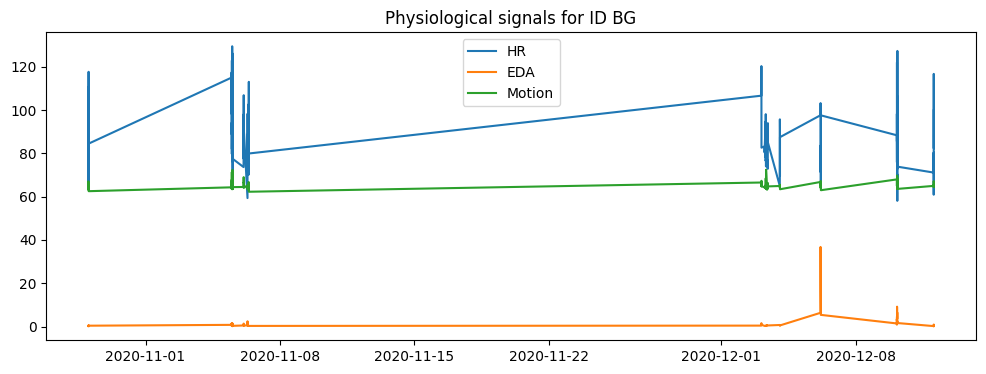

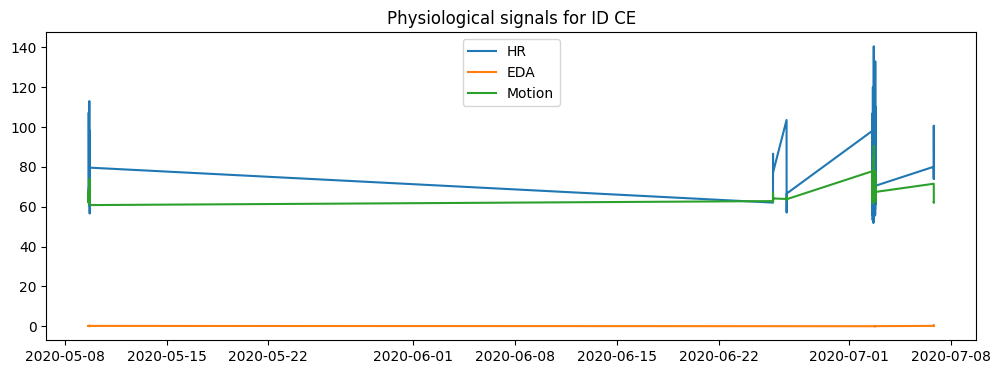

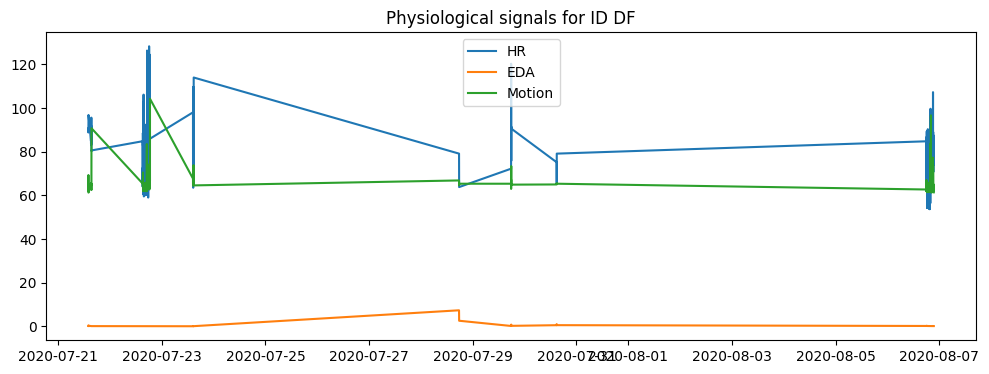

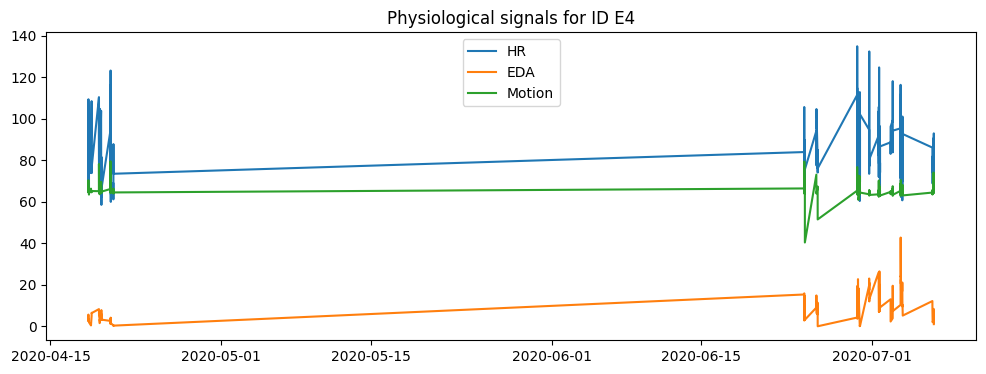

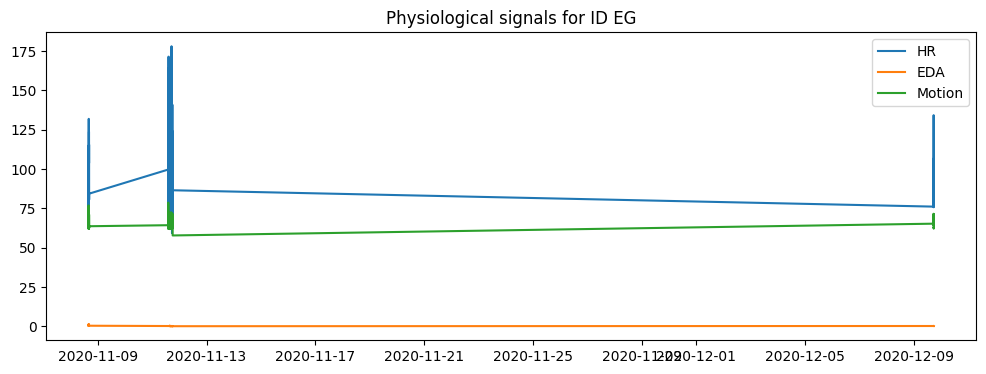

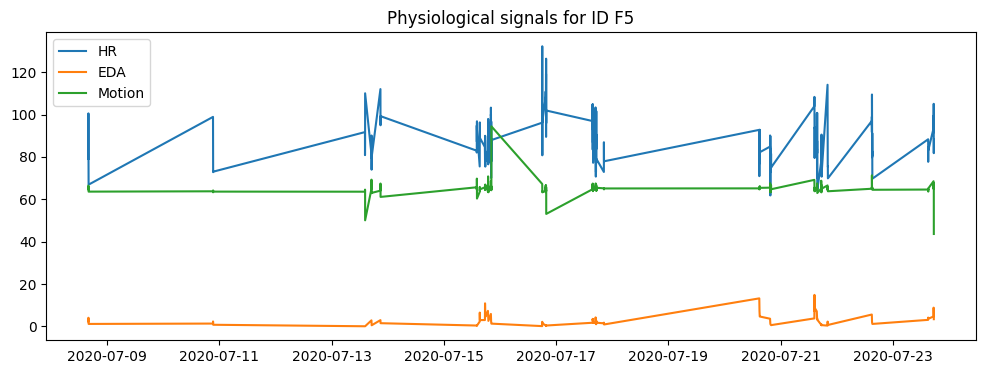

In [203]:
for uid in features30R['id'].unique():
    df_id = features30R[features30R['id']==uid].sort_values('datetime')
    plt.figure(figsize=(12,4))
    plt.plot(df_id['datetime'], df_id['HR'], label='HR')
    plt.plot(df_id['datetime'], df_id['EDA'], label='EDA')
    plt.plot(df_id['datetime'], df_id['Motion'], label='Motion')
    plt.title(f'Physiological signals for ID {uid}')
    plt.legend()
    plt.show()

look into dataset.head() and dataset.info()

I did so many EDA. this is after resampling 30s. I had 11 million rows now only 12.000 

I need to do some visuals but my datetime is different for every id. and their data is sampled like this 
frequent_ids = ['6B','6D','7E','F5','EG','8B','DF']      # daily or every 2 days
semi_frequent_ids = ['5C','7A','E4']       # twice a month
rare_ids = ['15','83','94','BG','CE']   # every 4-7 days

so I'm thinking I need threshold for HR so decide after wich could be stresss. and I cannot do anything with temp because it's skin temp and it's in normal range. temp_unique=[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
I also have motion. my motion is between 60-80 and have some datapoint around 140. 

thinking putting threshold. for all and filtering seeing what data has stress or too on. i did some but it looks like every hR >100 label can be 2,1,0 stress to non stress. so I really dont know what should I look into before ML. 

In [143]:
#here I tryed to change column and put threshold there to seee what is chanding

stress_highM = features30R[(features30R['Motion'] >90 )& (features30R['label'] == 1)]

# View the first few rows
len(stress_highM)



55

In [228]:
stress_highEDA = features30R[(features30R['EDA'] >10 )& (features30R['label'] ==2 )]

# View the first few rows
len(stress_highEDA

970

In [146]:
stress_highHR = features30R[(features30R['HR'] >120 )& (features30R['label'] ==2 )]

# View the first few rows
len(stress_highHR)

204

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


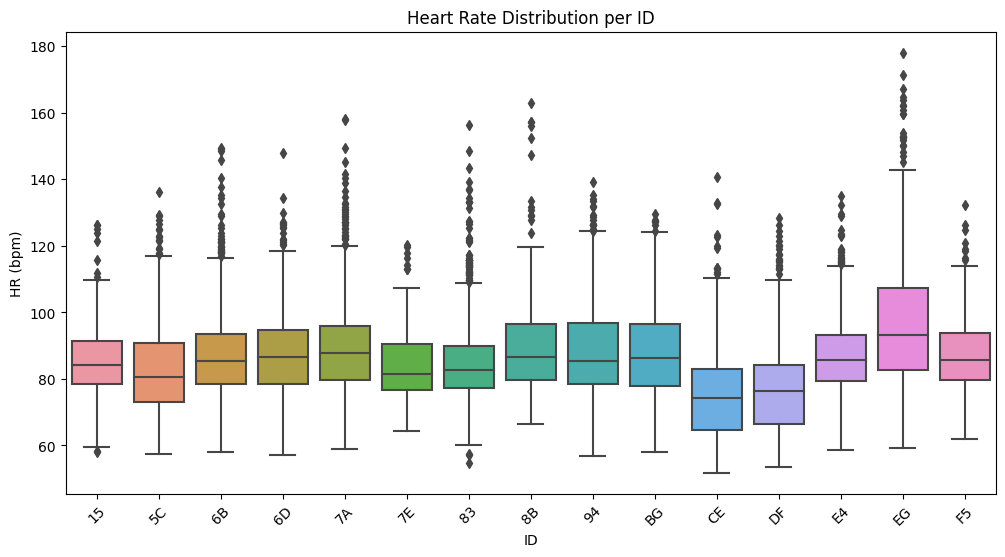

In [148]:
# HR distribution per ID
plt.figure(figsize=(12,6))
sns.boxplot(x='id', y='HR', data=features30R)
plt.xticks(rotation=45)
plt.title('Heart Rate Distribution per ID')
plt.ylabel('HR (bpm)')
plt.xlabel('ID')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


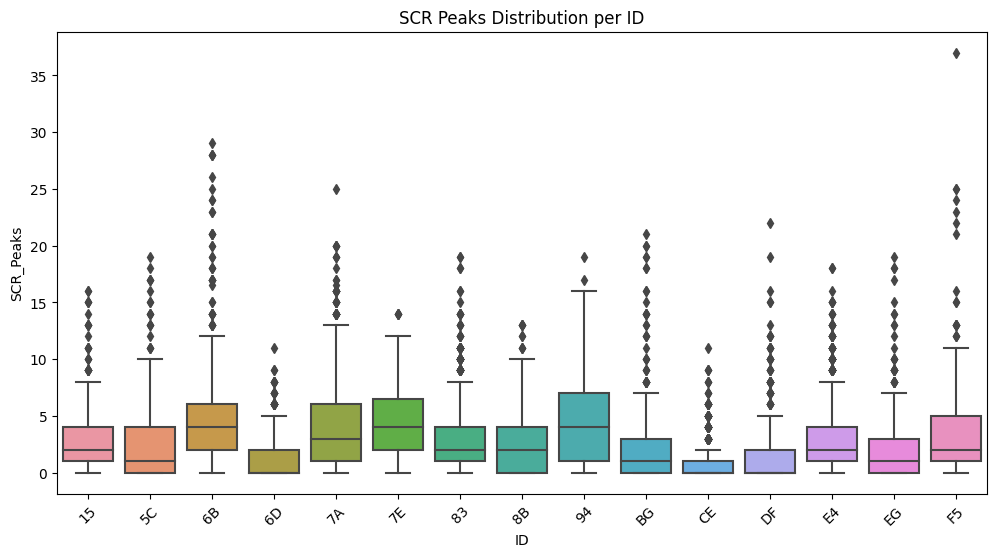

In [205]:
# HR distribution per ID
plt.figure(figsize=(12,6))
sns.boxplot(x='id', y='SCR_Peaks', data=features30R)
plt.xticks(rotation=45)
plt.title('SCR Peaks Distribution per ID')
plt.ylabel('SCR_Peaks')
plt.xlabel('ID')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


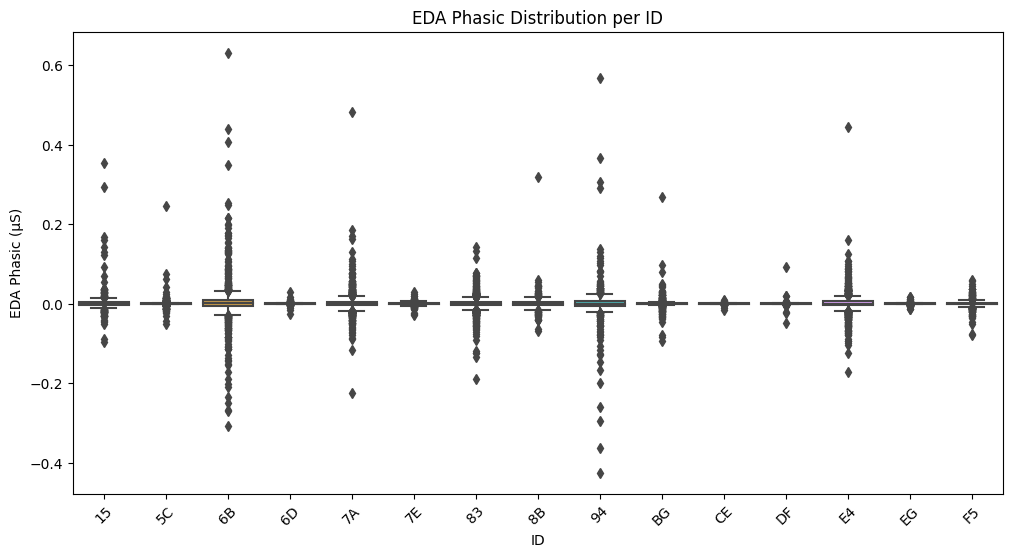

In [149]:
plt.figure(figsize=(12,6))
sns.boxplot(x='id', y='EDA_Phasic', data=features30R)
plt.xticks(rotation=45)
plt.title('EDA Phasic Distribution per ID')
plt.ylabel('EDA Phasic (µS)')
plt.xlabel('ID')
plt.show()

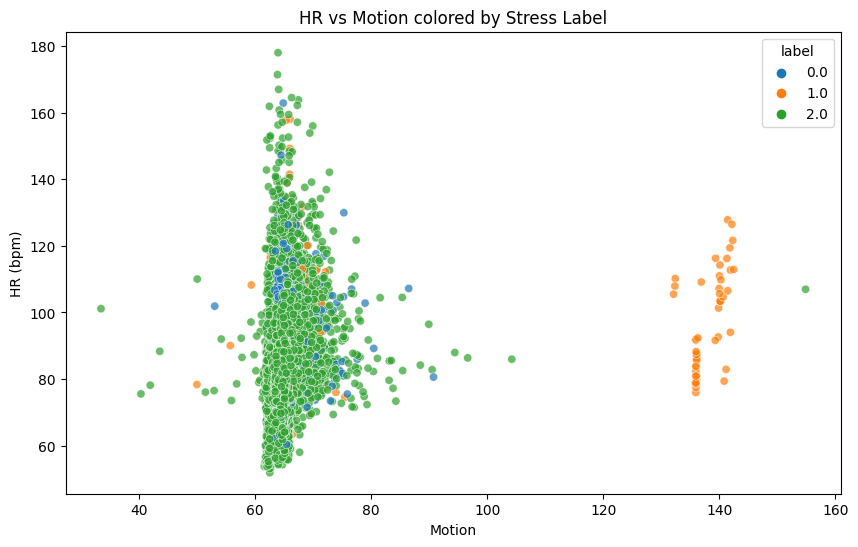

In [150]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Motion', y='HR', hue='label', data=features30R, alpha=0.7)
plt.title('HR vs Motion colored by Stress Label')
plt.xlabel('Motion')
plt.ylabel('HR (bpm)')
plt.show()

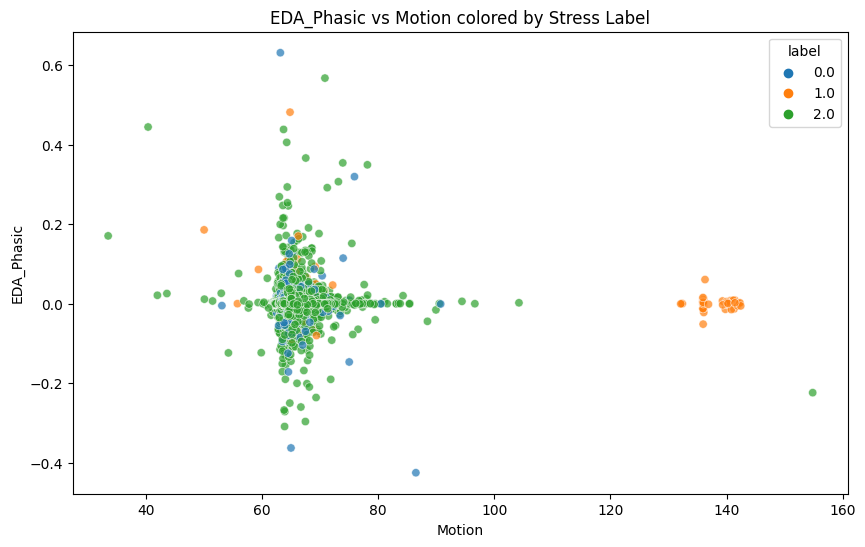

In [156]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Motion', y='EDA_Phasic', hue='label', data=features30R, alpha=0.7)
plt.title('EDA_Phasic vs Motion colored by Stress Label')
plt.xlabel('Motion')
plt.ylabel('EDA_Phasic')
plt.show()

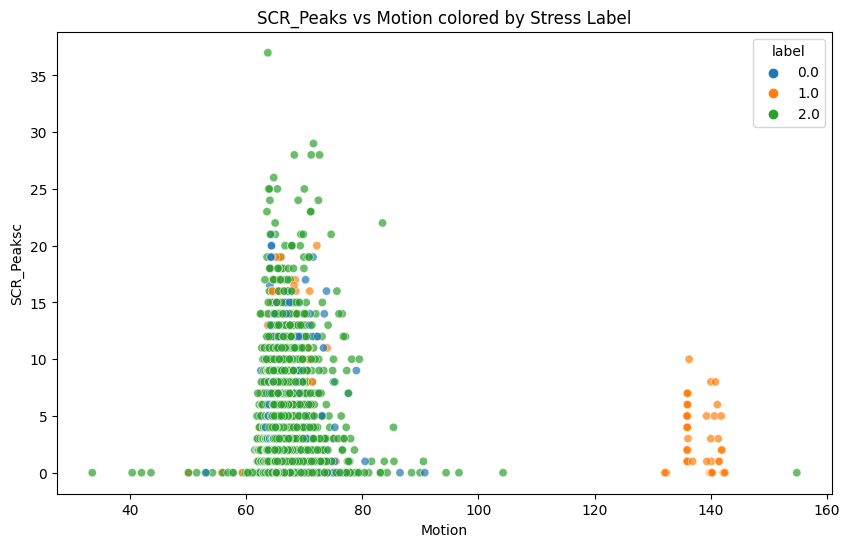

In [153]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Motion', y='SCR_Peaks', hue='label', data=features30R, alpha=0.7)
plt.title('SCR_Peaks vs Motion colored by Stress Label')
plt.xlabel('Motion')
plt.ylabel('SCR_Peaksc')
plt.show()

In [55]:
# Average stress level per day of week across all IDs
features30R['label_num'] = features30R['label'].astype(int)       #DONT FORGET TO delete this column if nnot needed
features30R.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12091 entries, 0 to 12090
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     12091 non-null  datetime64[ns]
 1   id           12091 non-null  category      
 2   Motion       12091 non-null  float64       
 3   Motion_std   12091 non-null  float64       
 4   Motion_mean  12091 non-null  float64       
 5   EDA          12091 non-null  float64       
 6   EDA_Tonic    12091 non-null  float64       
 7   EDA_Phasic   12091 non-null  float64       
 8   HR           12091 non-null  float64       
 9   HR_std       12091 non-null  float64       
 10  HR_mean      12091 non-null  float64       
 11  HR_diff      12091 non-null  float64       
 12  TEMP         12091 non-null  float64       
 13  hour_sin     12091 non-null  float64       
 14  hour_cos     12091 non-null  float64       
 15  day_sin      12091 non-null  float64       
 16  day_

This counts are showing that in that day or in that hour over the cours of record. that many time that id has stress level=2. 

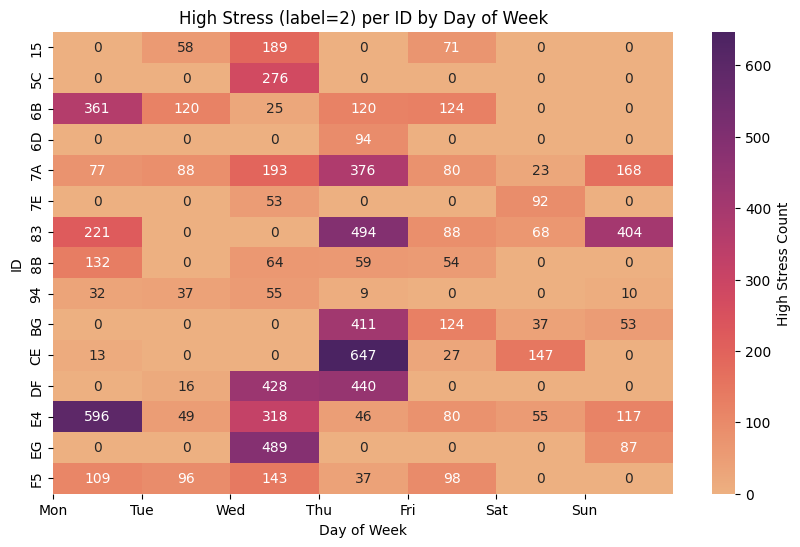

In [180]:
# Pivot data: rows=ID, columns=day_of_week
heatmap_data = weekly_high_stress.pivot(index='id', columns='day_of_week', values='count')

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,                  # show numbers in cells
    fmt='d',                     # format as integer
    cmap='flare',
    cbar_kws={'label':'High Stress Count'}
)
plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.ylabel('ID')
plt.xlabel('Day of Week')
plt.title('High Stress Events per ID by Day of Week')
plt.show()

/tmp/ipykernel_47/904508413.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_high_stress = high_stress.groupby(['id','hour']).size().reset_index(name='count')


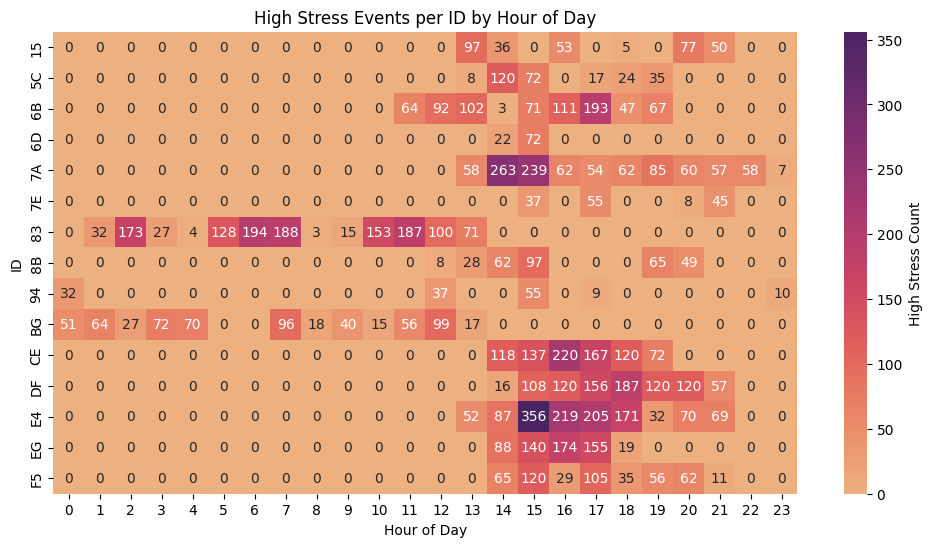

In [182]:
# Filter high stress
high_stress = features30R[features30R['label'] == 2]

# Count high stress events per ID per hour
hourly_high_stress = high_stress.groupby(['id','hour']).size().reset_index(name='count')

# Pivot for heatmap
heatmap_hour = hourly_high_stress.pivot(index='id', columns='hour', values='count').fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_hour, annot=True, fmt='d', cmap='flare', cbar_kws={'label':'High Stress Count'})
plt.xlabel('Hour of Day')
plt.ylabel('ID')
plt.title('High Stress Events per ID by Hour of Day')
plt.show()


In [187]:
# Count total rows per ID per day_of_week
samples_per_day = features30R.groupby(['id','day_of_week']).size().reset_index(name='total_samples')

print(samples_per_day.head(20))

    id  day_of_week  total_samples
0   15            0              0
1   15            1             73
2   15            2            189
3   15            3              0
4   15            4             71
5   15            5              0
6   15            6              0
7   5C            0              0
8   5C            1            413
9   5C            2            276
10  5C            3            180
11  5C            4             43
12  5C            5              0
13  5C            6              0
14  6B            0            422
15  6B            1            173
16  6B            2             25
17  6B            3            120
18  6B            4            124
19  6B            5              0


/tmp/ipykernel_47/1024461363.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_day = features30R.groupby(['id','day_of_week']).size().reset_index(name='total_samples')


In [186]:
# Count total rows per ID per day_of_week
samples_per_day = features30R.groupby(['id','hour']).size().reset_index(name='total_samples')

print(samples_per_day.head(20))

    id  hour  total_samples
0   15     0              0
1   15     1              0
2   15     2              0
3   15     3              0
4   15     4              0
5   15     5              0
6   15     6              0
7   15     7              0
8   15     8              0
9   15     9              0
10  15    10              0
11  15    11              0
12  15    12              0
13  15    13            112
14  15    14             36
15  15    15              0
16  15    16             53
17  15    17              0
18  15    18              5
19  15    19              0


/tmp/ipykernel_47/2703352043.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_day = features30R.groupby(['id','hour']).size().reset_index(name='total_samples')


/tmp/ipykernel_47/1335911738.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_stress_day = features30R[features30R['label_num'] == 2].groupby(['id','day_of_week']).size().reset_index(name='high_stress_count')
/tmp/ipykernel_47/1335911738.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_samples_day = features30R.groupby(['id','day_of_week']).size().reset_index(name='total_samples')
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


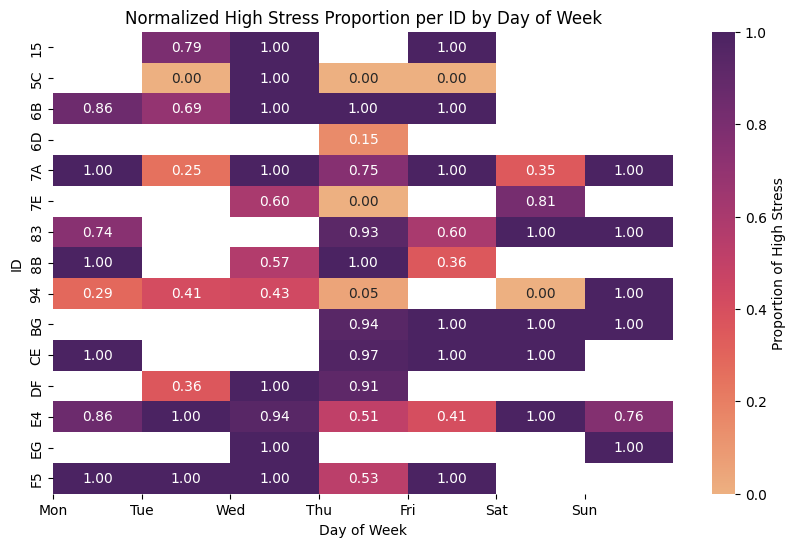

In [194]:
# Filter high stress events (label = 2)
high_stress = features30R[features30R['label_num'] == 2]

## Count high-stress events per ID per day
high_stress_day = features30R[features30R['label_num'] == 2].groupby(['id','day_of_week']).size().reset_index(name='high_stress_count')

# Count total samples per ID per day
total_samples_day = features30R.groupby(['id','day_of_week']).size().reset_index(name='total_samples')

# Merge and calculate proportion
daily = pd.merge(total_samples_day, high_stress_day, on=['id','day_of_week'], how='left')
daily['proportion'] = daily['high_stress_count'] / daily['total_samples']
daily['high_stress_count'] = daily['high_stress_count'].fillna(0)  # fill NaNs after merge

# Pivot for heatmap
heatmap_day = daily.pivot(index='id', columns='day_of_week', values='proportion')

# Plot
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_day, annot=True, fmt=".2f", cmap='flare', cbar_kws={'label':'Proportion of High Stress'})
plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.ylabel('ID')
plt.xlabel('Day of Week')
plt.title('Normalized High Stress Proportion per ID by Day of Week')
plt.show()

/tmp/ipykernel_47/937252640.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_stress_hour = features30R[features30R['label'] == 2].groupby(['id','hour']).size().reset_index(name='high_stress_count')
/tmp/ipykernel_47/937252640.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_samples_hour = features30R.groupby(['id','hour']).size().reset_index(name='total_samples')
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


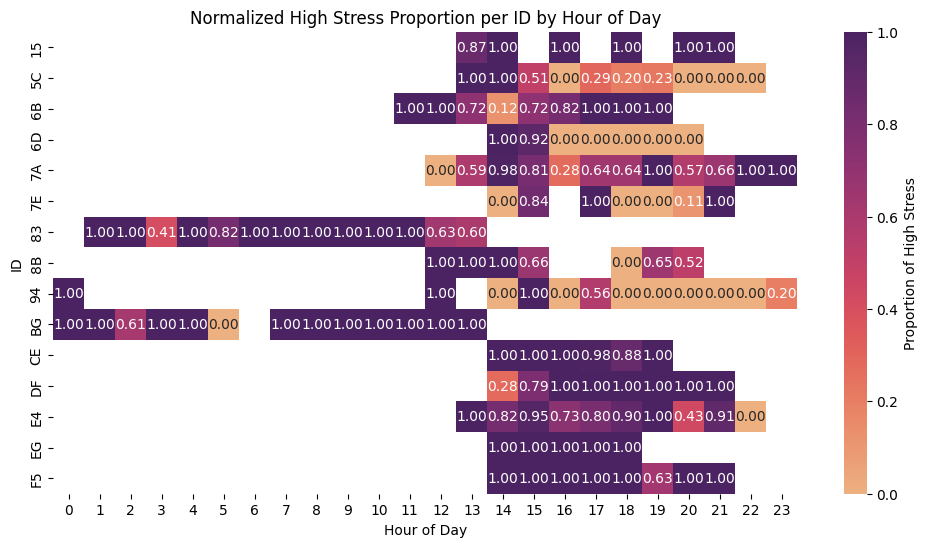

In [195]:
# Count high stress events per ID per hour
high_stress_hour = features30R[features30R['label'] == 2].groupby(['id','hour']).size().reset_index(name='high_stress_count')

# Count total samples per ID per hour
total_samples_hour = features30R.groupby(['id','hour']).size().reset_index(name='total_samples')

# Merge safely
hourly = pd.merge(total_samples_hour, high_stress_hour, on=['id','hour'], how='left')
hourly['high_stress_count'] = hourly['high_stress_count'].fillna(0)
hourly['proportion'] = hourly['high_stress_count'] / hourly['total_samples']

# Pivot for heatmap
heatmap_hour = hourly.pivot(index='id', columns='hour', values='proportion')

# Plot
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_hour, annot=True, fmt=".2f", cmap='flare', cbar_kws={'label':'Proportion of High Stress'})
plt.xlabel('Hour of Day')
plt.ylabel('ID')
plt.title('Normalized High Stress Proportion per ID by Hour of Day')
plt.show()

In [197]:


# Count of each stress level per ID per day
stress_counts = features30R.groupby(['id','day_of_week','label_num']).size().reset_index(name='count')

# Total samples per ID per day
total_day = features30R.groupby(['id','day_of_week']).size().reset_index(name='total')

# Merge and calculate percentage
stress_counts = stress_counts.merge(total_day, on=['id','day_of_week'])
stress_counts['percentage'] = (stress_counts['count'] / stress_counts['total']) * 100

/tmp/ipykernel_47/3583063055.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_counts = features30R.groupby(['id','day_of_week','label_num']).size().reset_index(name='count')
/tmp/ipykernel_47/3583063055.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_day = features30R.groupby(['id','day_of_week']).size().reset_index(name='total')


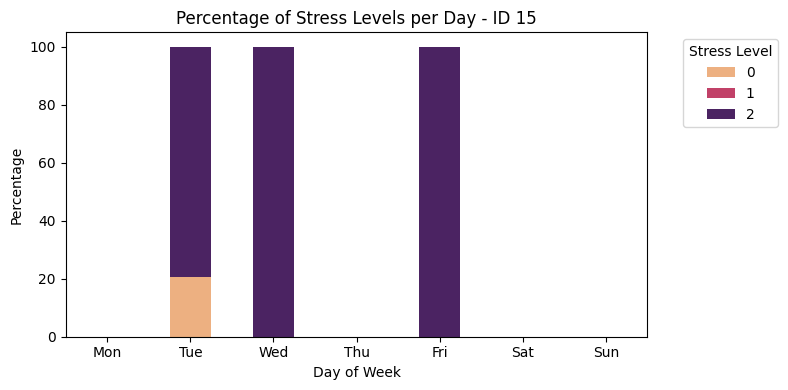

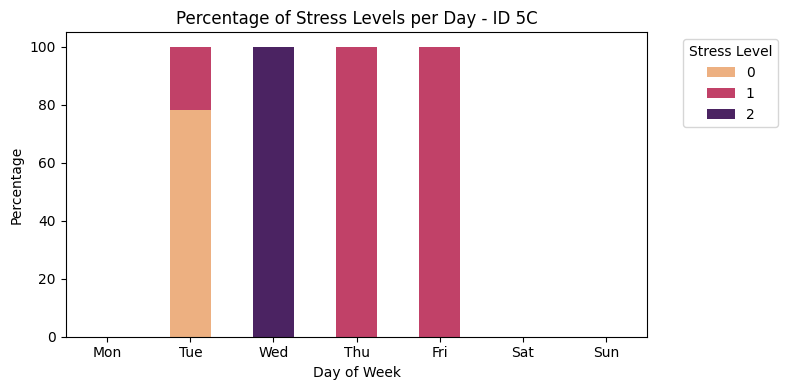

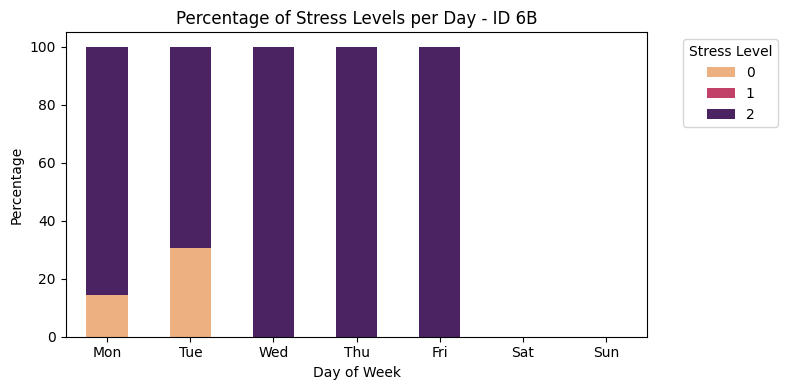

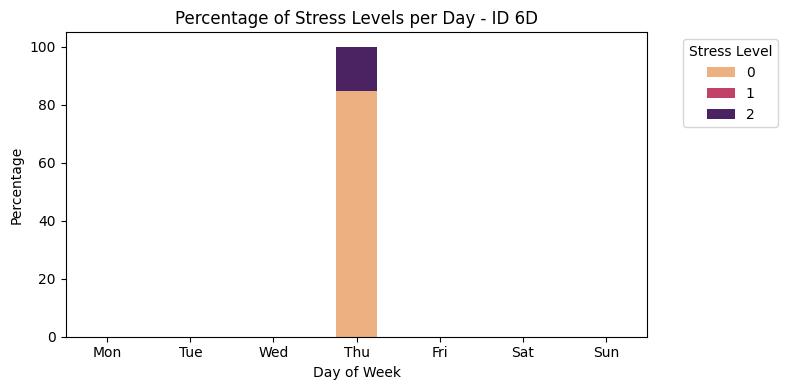

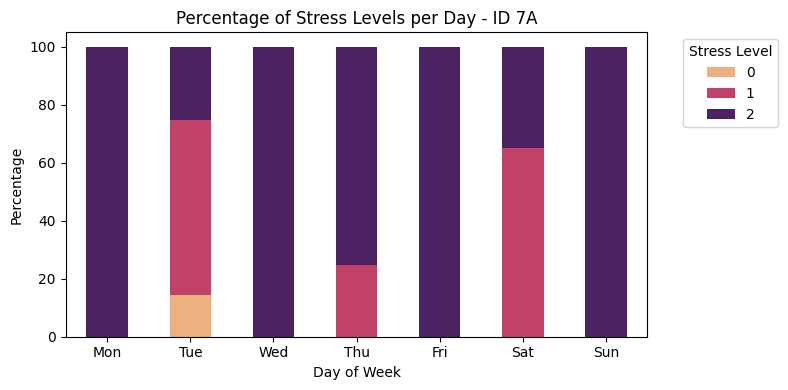

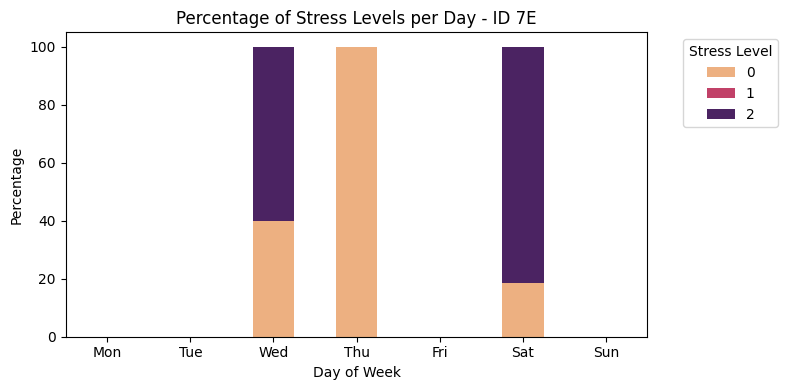

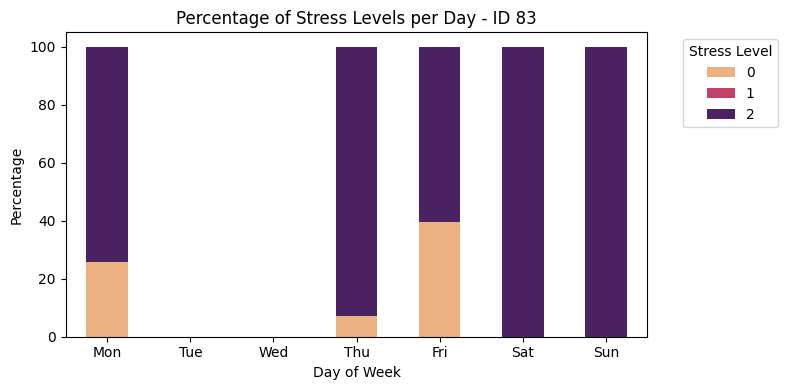

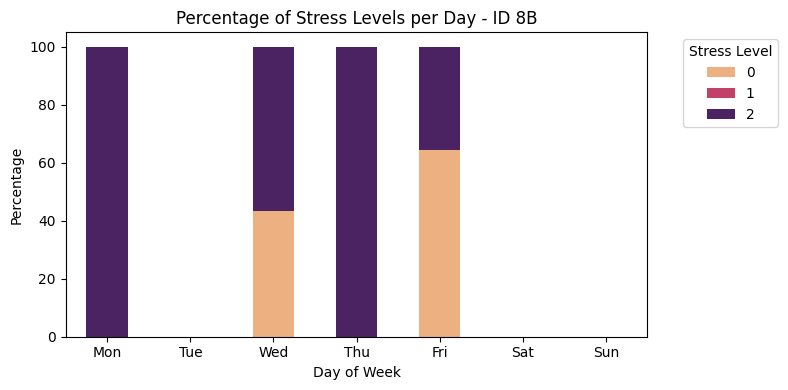

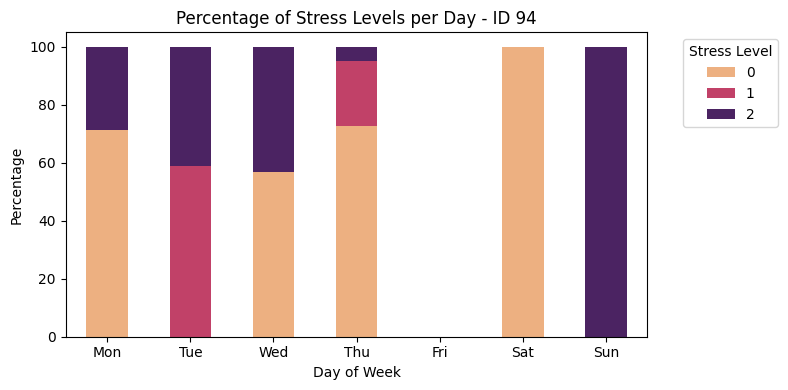

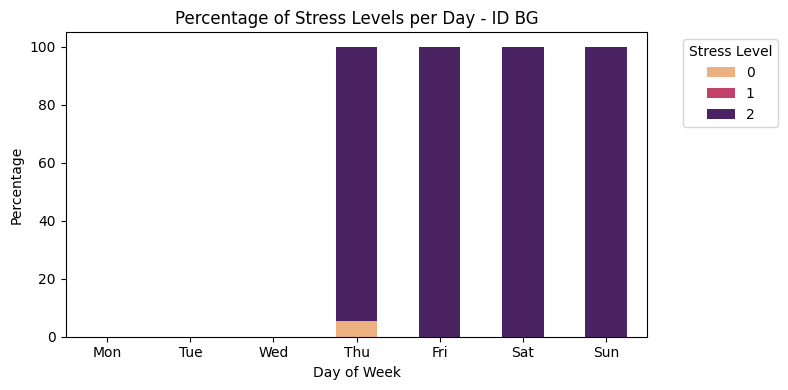

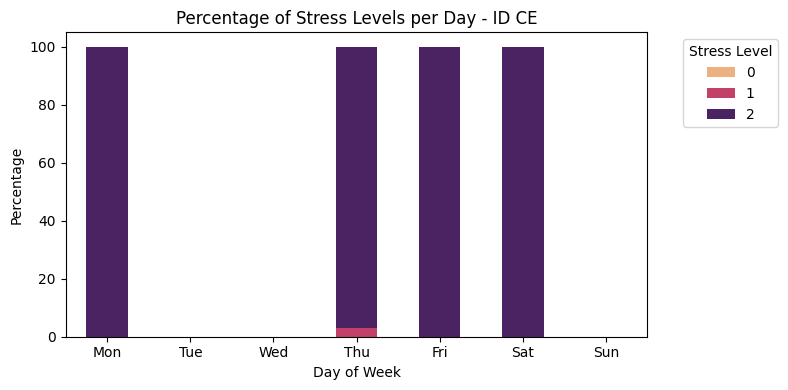

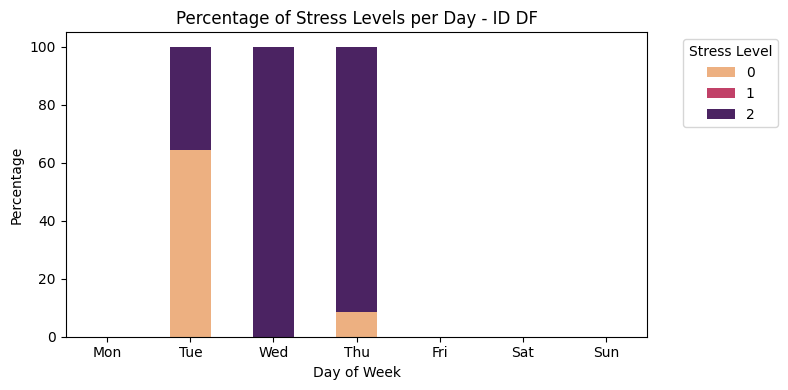

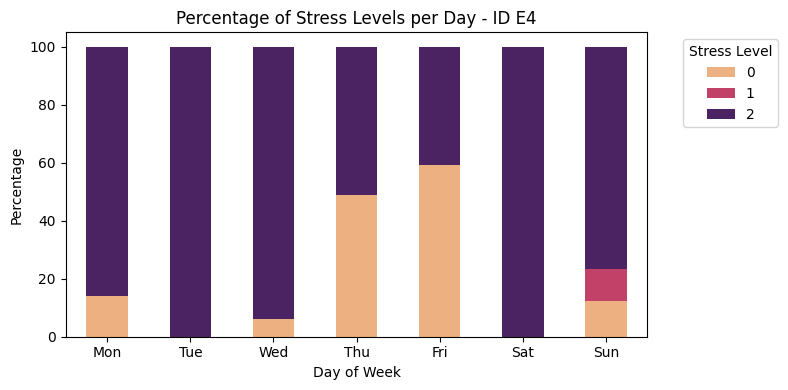

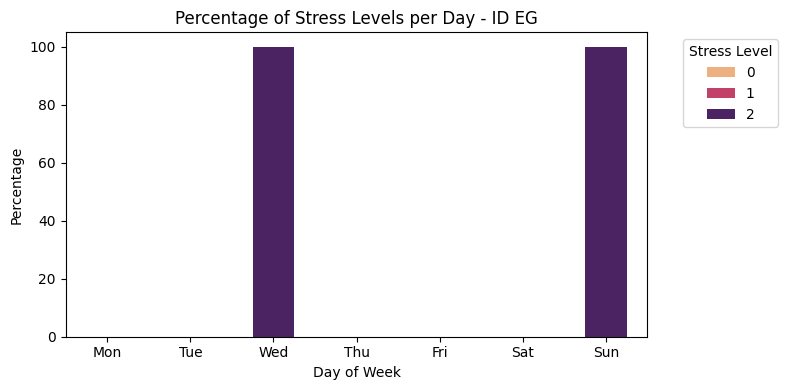

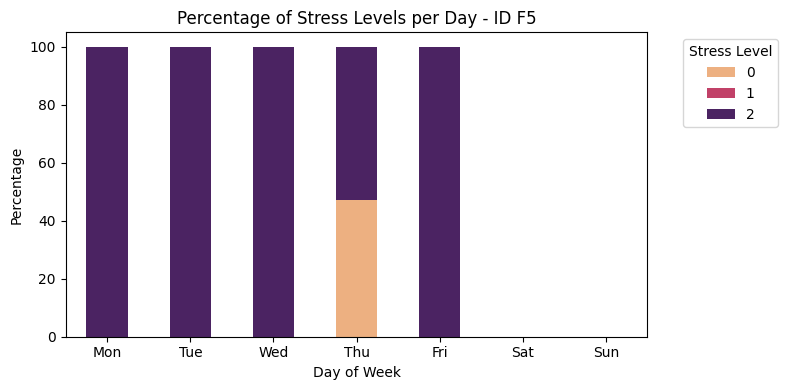

In [199]:
unique_ids = features30R['id'].unique()

for id_ in unique_ids:
    df_id = stress_counts[stress_counts['id']==id_].pivot(index='day_of_week', columns='label_num', values='percentage').fillna(0)
    
    # Plot stacked bar
    df_id.plot(kind='bar', stacked=True, figsize=(8,4), colormap='flare')
    
    plt.title(f'Percentage of Stress Levels per Day - ID {id_}')
    plt.ylabel('Percentage')
    plt.xlabel('Day of Week')
    plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
    plt.legend(title='Stress Level', bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [200]:
# Count of each stress level per ID per hour
stress_counts_hour = features30R.groupby(['id','hour','label_num']).size().reset_index(name='count')

# Total samples per ID per hour
total_hour = features30R.groupby(['id','hour']).size().reset_index(name='total')

# Merge and calculate percentage
stress_counts_hour = stress_counts_hour.merge(total_hour, on=['id','hour'])
stress_counts_hour['percentage'] = (stress_counts_hour['count'] / stress_counts_hour['total']) * 100

/tmp/ipykernel_47/702940186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_counts_hour = features30R.groupby(['id','hour','label_num']).size().reset_index(name='count')
/tmp/ipykernel_47/702940186.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_hour = features30R.groupby(['id','hour']).size().reset_index(name='total')


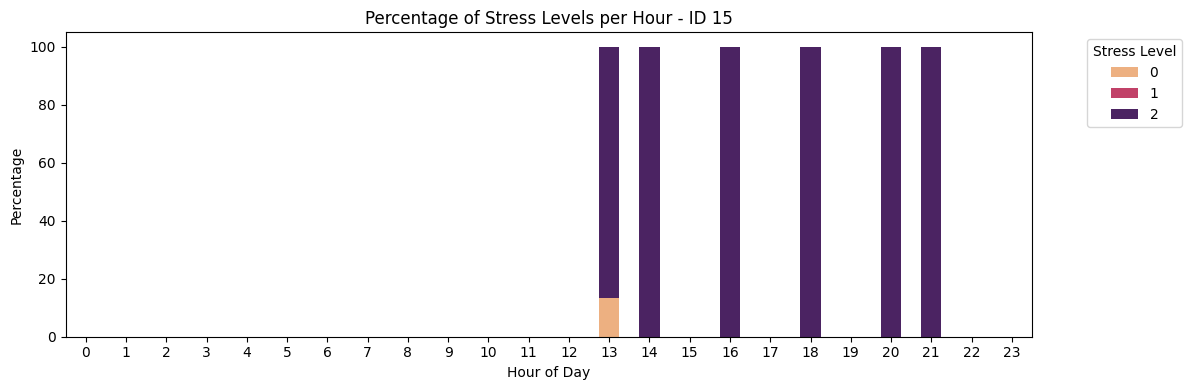

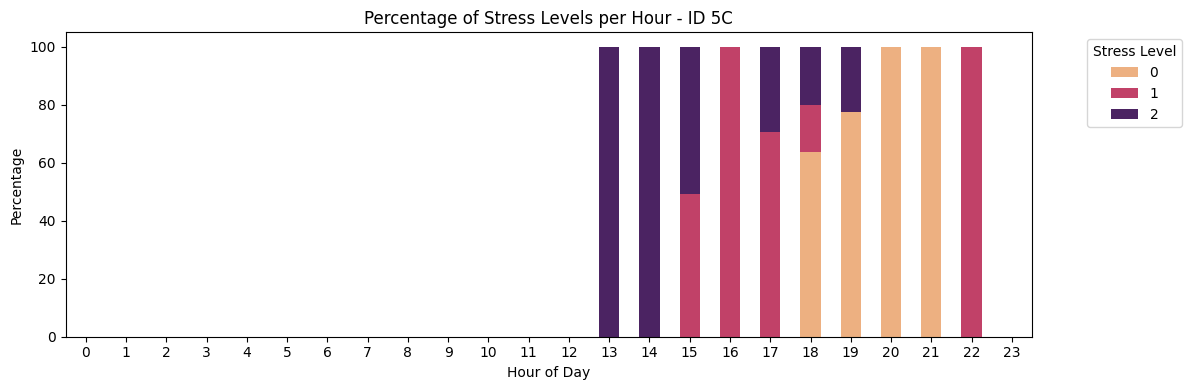

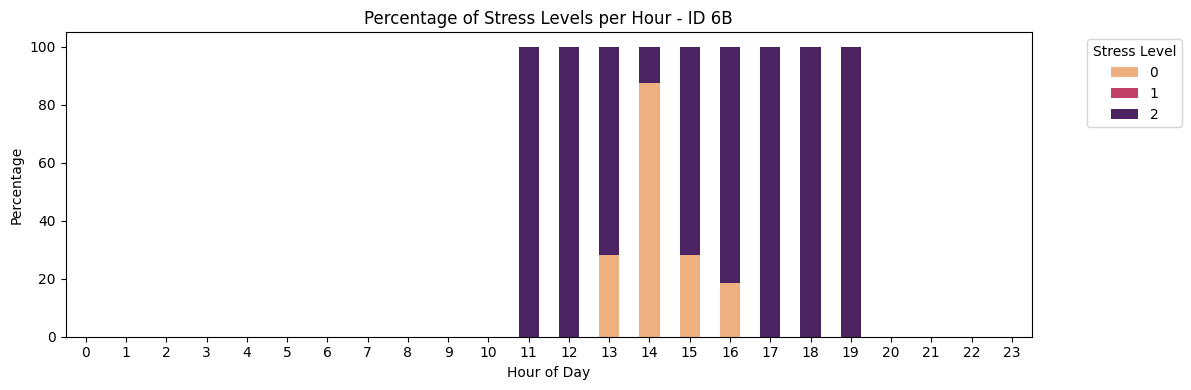

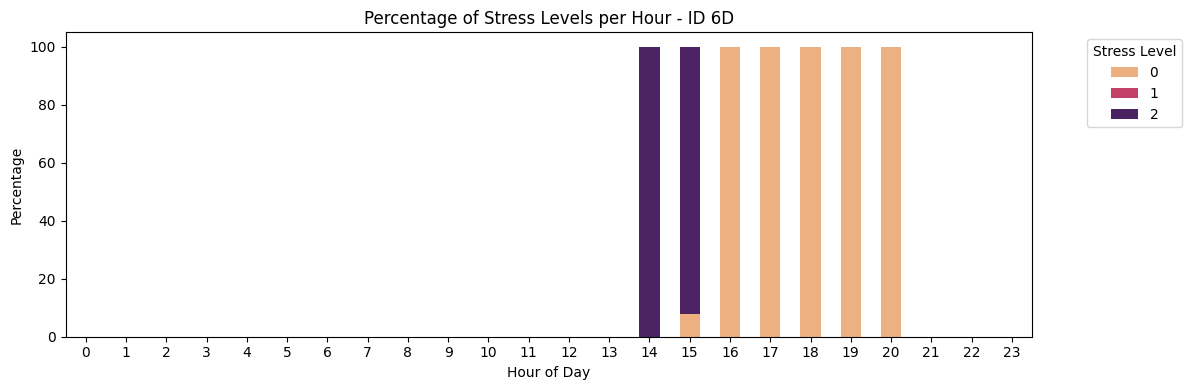

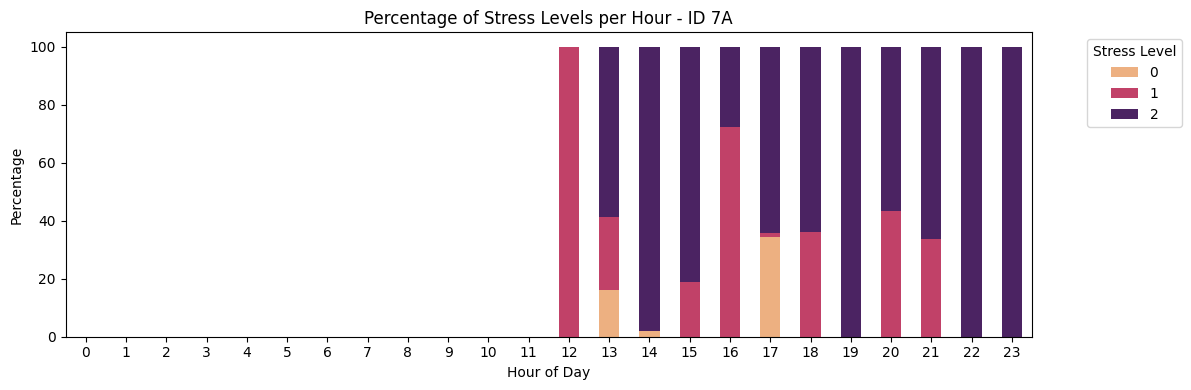

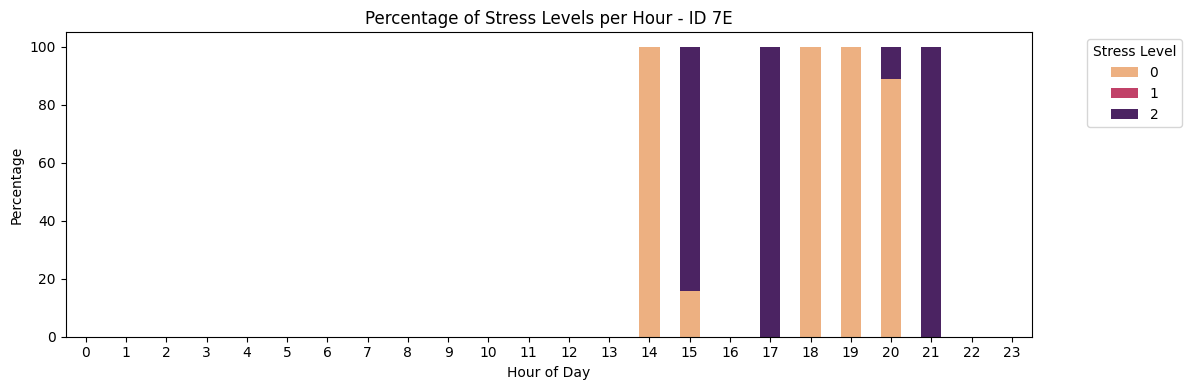

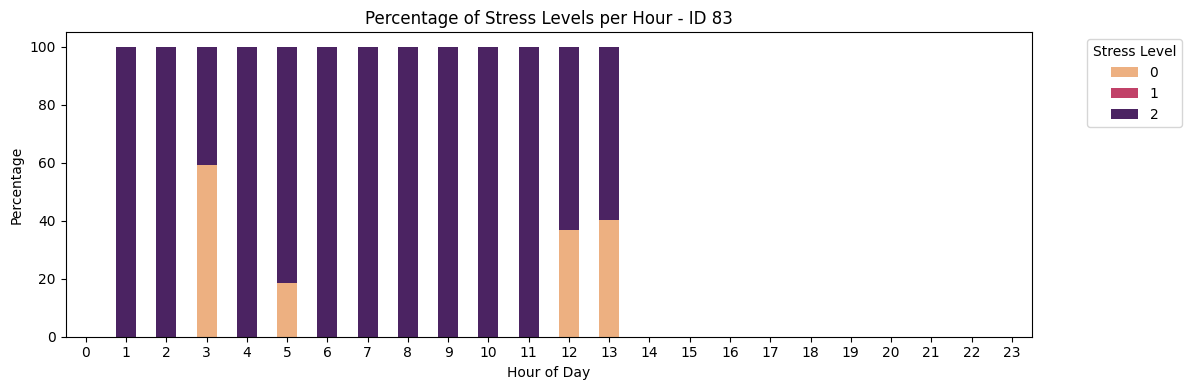

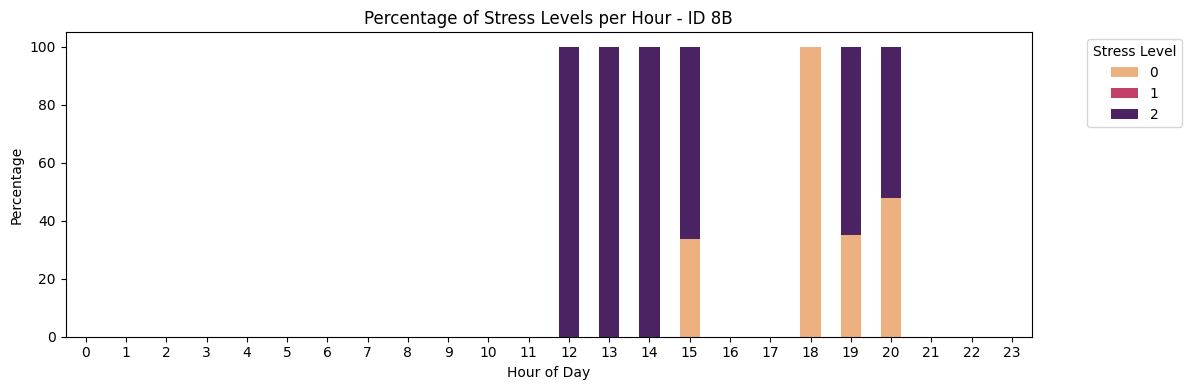

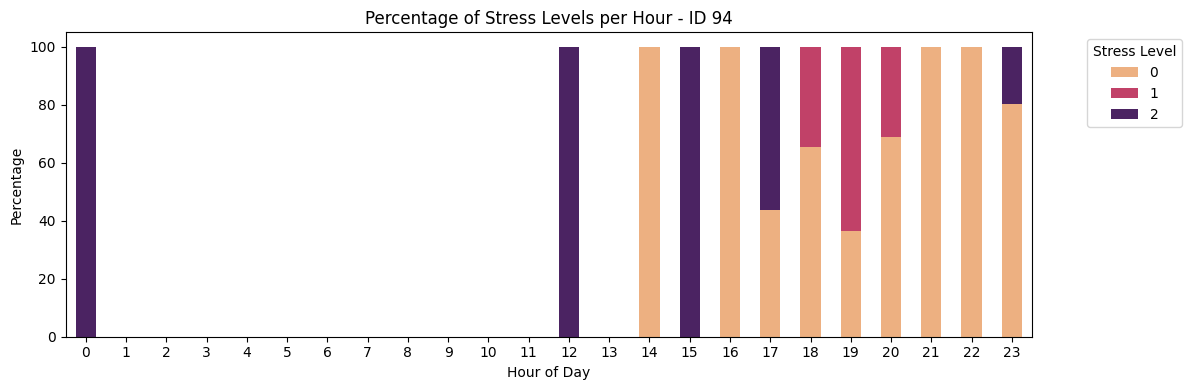

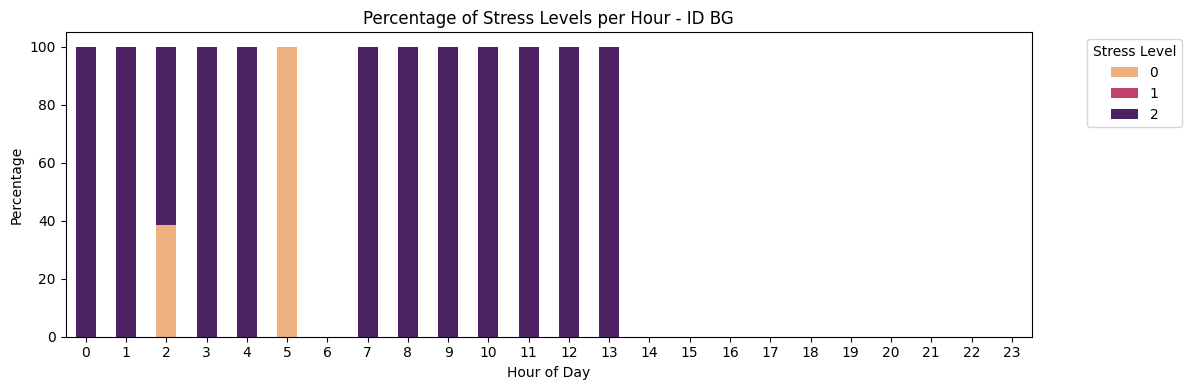

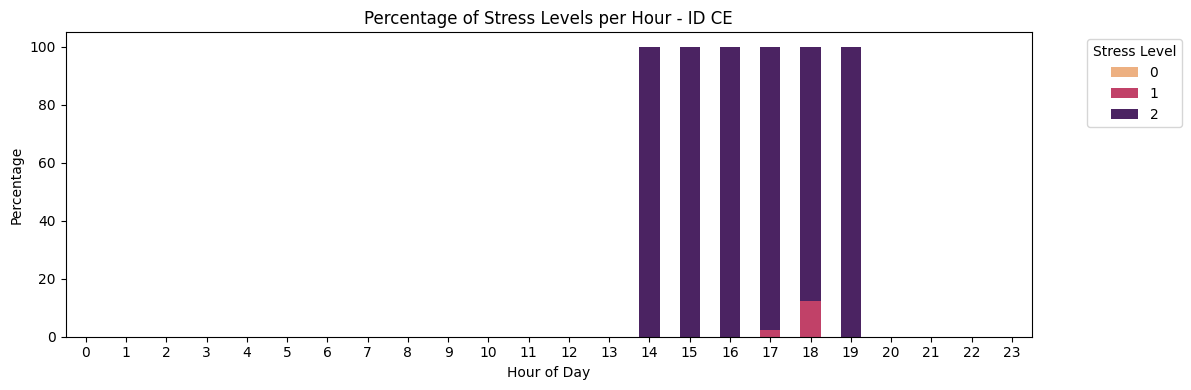

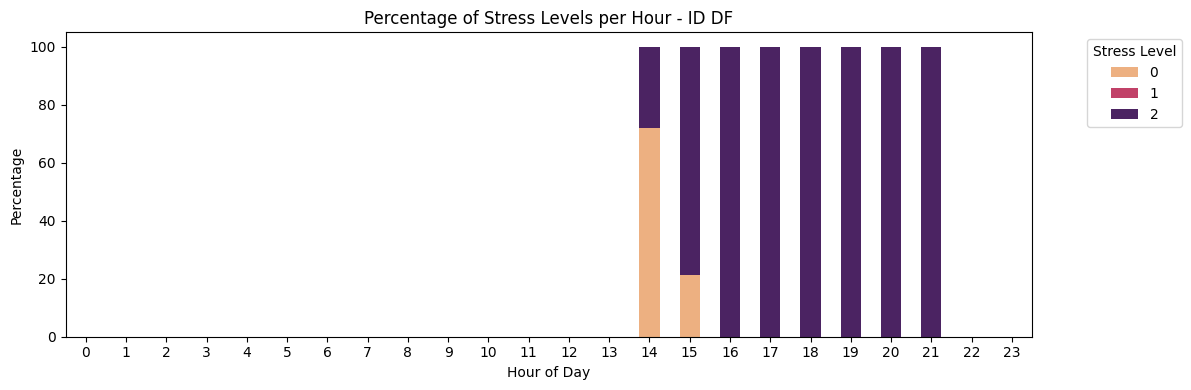

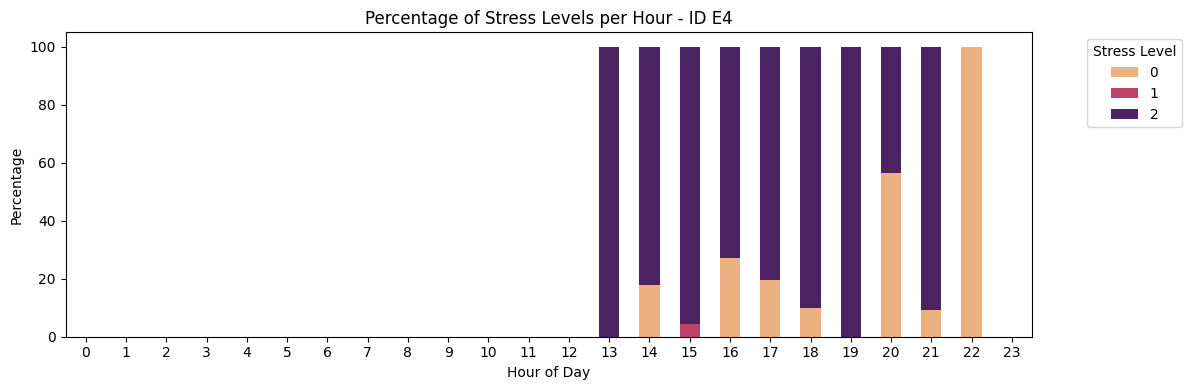

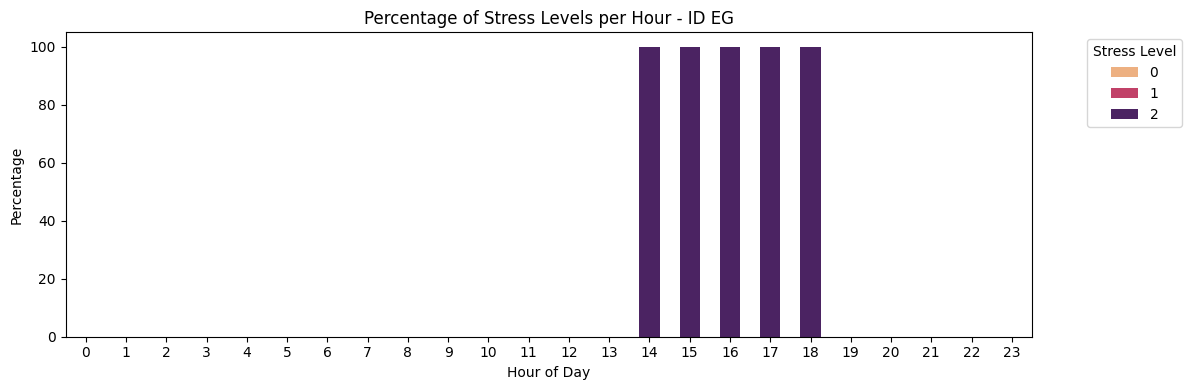

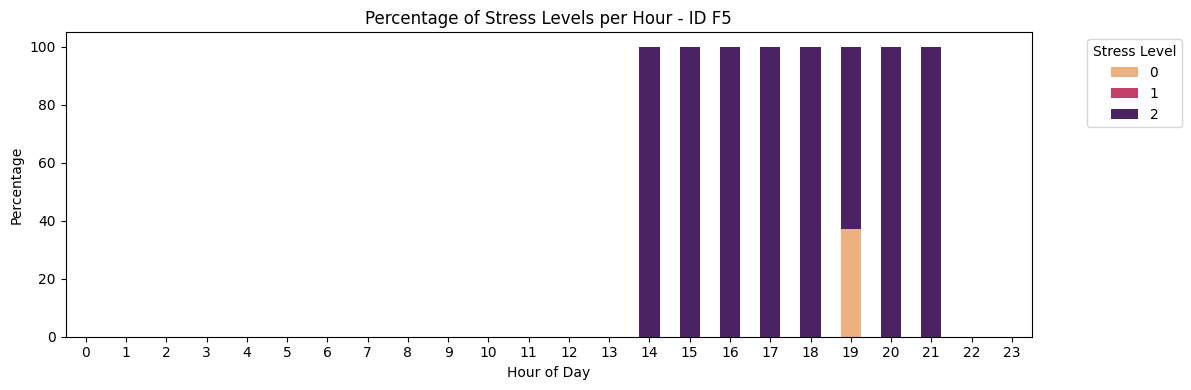

In [202]:
unique_ids = features30R['id'].unique()

for id_ in unique_ids:
    df_id = stress_counts_hour[stress_counts_hour['id']==id_].pivot(index='hour', columns='label_num', values='percentage').fillna(0)
    
    # Plot stacked bar
    df_id.plot(kind='bar', stacked=True, figsize=(12,4), colormap='flare')
    
    plt.title(f'Percentage of Stress Levels per Hour - ID {id_}')
    plt.ylabel('Percentage')
    plt.xlabel('Hour of Day')
    plt.xticks(rotation=0)
    plt.legend(title='Stress Level', bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

**ML**
Normalize numeric features

Feed to ML model (Random Forest / XGBoost)
Check feature importance → identify which signals/time features matter most
Optional: remove low-importance features to simplify model

keep target (label) numeric

drop id because we are not doing prediction for id's this is a general prediction model 

we need to deal with label 0,1,2 meanings. 




In [226]:
(features30R==0).sum()  # drop , datetime,id,label. but we can do feature importance for tree based model     
#max_HR, mean_EDA_Phasic,max_EDA_Phasic,day_of_week/hour

datetime          0
id                0
Motion            0
Motion_std        0
Motion_mean       0
EDA               0
EDA_Tonic         0
EDA_Phasic        0
HR                0
HR_std           28
HR_mean           0
HR_diff           0
TEMP              0
hour_sin         83
hour_cos          0
day_sin        1857
day_cos           0
label          2290
SCR_Peaks      3819
date              0
hour             83
day_of_week    1857
label_num      2290
dtype: int64

In [72]:
features30R.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12091 entries, 0 to 12090
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     12091 non-null  datetime64[ns]
 1   id           12091 non-null  category      
 2   Motion       12091 non-null  float64       
 3   Motion_std   12091 non-null  float64       
 4   Motion_mean  12091 non-null  float64       
 5   EDA          12091 non-null  float64       
 6   EDA_Tonic    12091 non-null  float64       
 7   EDA_Phasic   12091 non-null  float64       
 8   HR           12091 non-null  float64       
 9   HR_std       12091 non-null  float64       
 10  HR_mean      12091 non-null  float64       
 11  HR_diff      12091 non-null  float64       
 12  TEMP         12091 non-null  float64       
 13  hour_sin     12091 non-null  float64       
 14  hour_cos     12091 non-null  float64       
 15  day_sin      12091 non-null  float64       
 16  day_

In [57]:
#use label_num as target variables(numeric) easy for ML
#id  causes data leakege drop it
#label categorical so drop it 
#datetime,date,hour,date_of_week drop them  are not useful they don t describe anything , cause noise, 
features30RL=features30R.copy()

In [58]:
features30RL = features30RL.drop(columns=['id','datetime','date','hour','day_of_week','label'])    #we removed 6 columns 

In [59]:
features30RL.head()  #we have 17 columns left 

,Motion,Motion_std,Motion_mean,EDA,EDA_Tonic,EDA_Phasic,HR,HR_std,HR_mean,HR_diff,TEMP,hour_sin,hour_cos,day_sin,day_cos,SCR_Peaks,label_num
0,66.134039,10.935840,66.325736,3.088903,3.088327,0.000890,74.364667,-0.005443,75.848496,0.909060,32.407000,-0.258819,-0.965926,0.974928,-0.222521,14.0,2
1,64.258897,6.271229,64.956438,1.522436,1.565033,0.028335,72.243611,-0.003067,73.006016,0.939526,32.471481,-0.258819,-0.965926,0.974928,-0.222521,15.0,2
2,64.609371,5.741256,64.625065,3.400481,3.380872,0.019598,68.674667,-0.000260,70.092268,1.493157,32.409333,-0.258819,-0.965926,0.974928,-0.222521,8.0,2
3,64.915591,7.668255,64.892687,3.897341,3.882470,0.014823,69.839000,0.004115,69.084301,0.407095,32.733667,-0.258819,-0.965926,0.974928,-0.222521,11.0,2
4,64.896254,6.718946,64.803544,4.173519,4.144828,0.028575,75.374333,0.003677,72.695872,1.827178,33.053000,-0.258819,-0.965926,0.974928,-0.222521,10.0,2


In [61]:
X=features30RL.drop(columns=['label_num'])
y=features30RL['label_num']

In [62]:
#normilize features 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import warnings 
warnings.filterwarnings('ignore')

In [63]:
#split
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.1, random_state=42, stratify=y)

In [64]:
#scaler only on trainin data 
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [65]:
#Random Forest
rf=RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42  
)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [66]:
#evaluating model
y_pred=rf.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test,y_pred))

0.9752066115702479
0.9596838594707776
              precision    recall  f1-score   support

           0       0.98      0.91      0.95       229
           1       1.00      0.90      0.95        82
           2       0.97      1.00      0.98       899

    accuracy                           0.98      1210
   macro avg       0.98      0.94      0.96      1210
weighted avg       0.98      0.98      0.97      1210



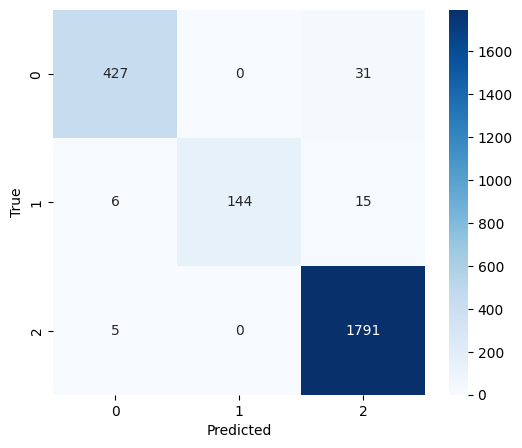

In [91]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


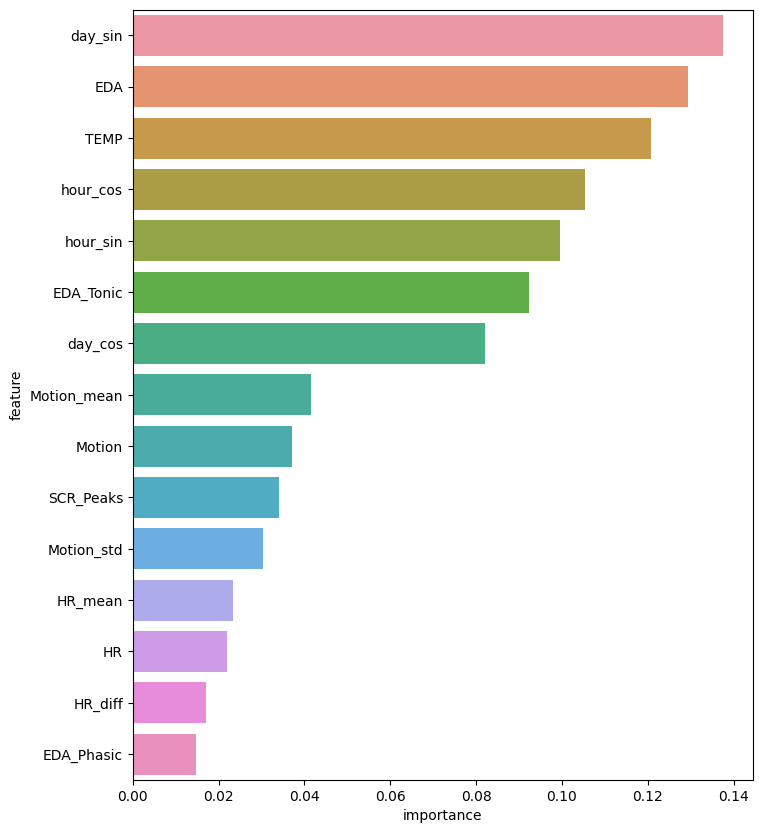

In [67]:
#feature importance
importances=rf.feature_importances_
feature_names=X.columns

fi=pd.DataFrame({ 'feature':  feature_names, 'importance': importances})
fi=fi.sort_values('importance', ascending= False)
plt.figure(figsize=(8,10))
sns.barplot(data=fi.head(15), x='importance',y='feature')
plt.show()

In [70]:
#Logistic Regression
lr=LogisticRegression(random_state=42, multi_class='multinomial',class_weight='balanced', solver='lbfgs', max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_predLR=lr.predict(X_test_scaled)

print(accuracy_score(y_test, y_predLR))
print(f1_score(y_test, y_predLR, average='macro'))
print(classification_report(y_test,y_predLR))


0.5619834710743802
0.48207708665970866
              precision    recall  f1-score   support

           0       0.38      0.64      0.47       229
           1       0.20      0.68      0.31        82
           2       0.89      0.53      0.66       899

    accuracy                           0.56      1210
   macro avg       0.49      0.62      0.48      1210
weighted avg       0.74      0.56      0.60      1210



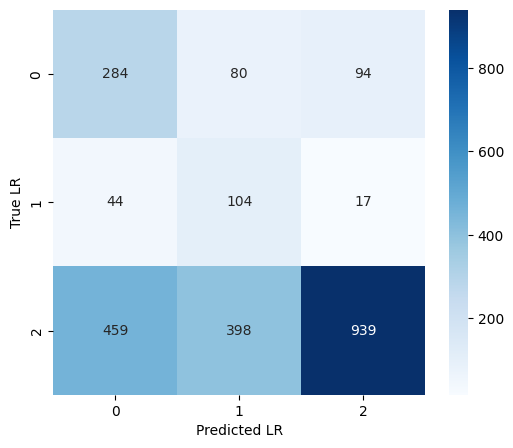

In [101]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_predLR), annot=True, cmap='Blues',fmt='d')
plt.xlabel('Predicted LR')
plt.ylabel('True LR')
plt.show()

In [71]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
#from imblearn.over_sampling import SMOTE, RamdonOverSampler

In [99]:
#XGBoosting lightGBM

tscv=TimeSeriesSplit(n_splits=5)


for fold,( train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test= X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test= y.iloc[train_idx], y.iloc[test_idx]
    
    weights= compute_sample_weight(class_weight='balanced', y=y_train)

    xgb=XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metrix='mlogloss',
        use_label_encoder=False,
        scale_pos_weight=None,
    random_state=42)
    
    xgb.fit(X_train, y_train, sample_weight=weights)
    y_predxgb=xgb.predict(X_test)

In [100]:
print(f'Fold {fold+1}')
print (accuracy_score(y_test, y_predxgb))
print(f1_score(y_test, y_predxgb, average='macro'))
print(classification_report(y_test, y_predxgb))

Fold 5
0.6937965260545905
0.33714759959366963
              precision    recall  f1-score   support

           0       0.18      0.22      0.20       313
           1       0.00      0.00      0.00         0
           2       0.85      0.78      0.81      1702

    accuracy                           0.69      2015
   macro avg       0.34      0.33      0.34      2015
weighted avg       0.74      0.69      0.72      2015



balance yaptin  yapmadan once 
accuracy =0.7384
f1= 0.3644

with balace
Fold 5
0.6937965260545905
0.33714759959366963


In [75]:
#lightGBM

import lightgbm as lgb

In [101]:
tscv=TimeSeriesSplit(n_splits=5)

for fold,( train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test= X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test= y.iloc[train_idx], y.iloc[test_idx]
    
    weights= compute_sample_weight(class_weight='balanced', y=y_train)

    lgbm=lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        boosting_type='gbdt',
        random_state=42,
        class_weight='balanced')
    
    lgbm.fit(X_train, y_train, sample_weight=weights)
    y_predlgbm=lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2862
[LightGBM] [Info] Number of data points in the train set: 2016, number of used features: 16
[LightGBM] [Info] Start training from score -1.031546
[LightGBM] [Info] Start training from score -0.664067
[LightGBM] [Info] Start training from score -2.049563
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [102]:
print(f'Fold {fold+1}')
print (accuracy_score(y_test, y_predlgbm))
print(f1_score(y_test, y_predlgbm, average='macro'))
print(classification_report(y_test, y_predlgbm))

Fold 5
0.6689826302729529
0.3298759001072468
              precision    recall  f1-score   support

           0       0.17      0.23      0.19       313
           1       0.00      0.00      0.00         0
           2       0.85      0.75      0.80      1702

    accuracy                           0.67      2015
   macro avg       0.34      0.33      0.33      2015
weighted avg       0.74      0.67      0.70      2015



only balanced with class_weight.
Fold 5
0.7121588089330024
0.34271331945223443

balanced with sample weight 
Fold 5
0.6689826302729529
0.3298759001072468



In [103]:
#gradient boostign
from sklearn.ensemble import HistGradientBoostingClassifier
grad
f1_scores=[]

tscv=TimeSeriesSplit(n_splits=5)

for fold,( train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test= X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test= y.iloc[train_idx], y.iloc[test_idx]
    
    weights= compute_sample_weight(class_weight='balanced', y=y_train)

    gglf=HistGradientBoostingClassifier(
        #n_estimators=100,
        learning_rate=0.5,
        max_depth=5,
        early_stopping=True,
    random_state=42)
    
    gglf.fit(X_train, y_train, sample_weight=weights)
    y_predgglf=gglf.predict(X_test)

In [104]:

#print (accuracy_score(y_test, y_predclf))
f1=f1_score(y_test, y_predgglf, average='macro')
f1_scores.append(f1)
print(f'Fold {fold+1} - Macro F1: {f1:.3f}')
print(classification_report(y_test, y_predgglf))

Fold 5 - Macro F1: 0.335
              precision    recall  f1-score   support

           0       0.18      0.19      0.19       313
           1       0.00      0.00      0.00         0
           2       0.84      0.80      0.82      1702

    accuracy                           0.70      2015
   macro avg       0.34      0.33      0.34      2015
weighted avg       0.74      0.70      0.72      2015



SMOTE STARTS HERE 

In [92]:
# run this to  kaggle terminal --> !pip install --force-reinstall imbalanced-learn==0.12.2

from imblearn.over_sampling import RandomOverSampler, SMOTE
from collections import Counter

In [106]:
smote=SMOTE(random_state=42)
X_res, y_res= smote.fit_resample(X_train, y_train)

print(Counter(y_res))


model=XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42)
model.fit(X_res, y_res)

y_predSMOTE=model.predict(X_test)
print("XGBClassifier:", classification_report(y_test, y_predSMOTE))

Counter({2: 7276, 0: 7276, 1: 7276})
XGBClassifier:               precision    recall  f1-score   support

           0       0.28      0.22      0.25       313
           1       0.00      0.00      0.00         0
           2       0.85      0.82      0.84      1702

    accuracy                           0.73      2015
   macro avg       0.38      0.35      0.36      2015
weighted avg       0.76      0.73      0.74      2015



In [107]:
import lightgbm as lgb 

gb_model=GradientBoostingClassifier(random_state=42)
gb_model.fit(X_res, y_res)
y_pred_gb=gb_model.predict(X_test)

In [108]:
lgb_model=lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_res, y_res)
y_pred_lgb=lgb_model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4079
[LightGBM] [Info] Number of data points in the train set: 21828, number of used features: 16
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


In [109]:
print("Gradient Boosting Metric: ", classification_report(y_test, y_pred_gb))
print("LightGBM Metrics:", classification_report(y_test, y_pred_lgb))

Gradient Boosting Metric:                precision    recall  f1-score   support

           0       0.29      0.25      0.27       313
           1       0.00      0.00      0.00         0
           2       0.87      0.80      0.84      1702

    accuracy                           0.72      2015
   macro avg       0.39      0.35      0.37      2015
weighted avg       0.78      0.72      0.75      2015

LightGBM Metrics:               precision    recall  f1-score   support

           0       0.33      0.23      0.27       313
           1       0.00      0.00      0.00         0
           2       0.86      0.86      0.86      1702

    accuracy                           0.76      2015
   macro avg       0.40      0.36      0.38      2015
weighted avg       0.78      0.76      0.77      2015



In [110]:
from sklearn.linear_model import LogisticRegression
LRSMOTE=LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
LRSMOTE.fit(X_res, y_res)
y_predlrsmote=LRSMOTE.predict(X_test)
print(accuracy_score(y_test, y_predlrsmote))
print(f1_score(y_test, y_predlrsmote, average='macro'))
      
print("LR with SMOTE:", classification_report(y_test, y_predlrsmote))


0.43424317617866004
0.28501272791904
LR with SMOTE:               precision    recall  f1-score   support

           0       0.22      0.41      0.28       313
           1       0.00      0.00      0.00         0
           2       0.82      0.44      0.57      1702

    accuracy                           0.43      2015
   macro avg       0.35      0.28      0.29      2015
weighted avg       0.73      0.43      0.53      2015



In [111]:
rf_smote=RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_res, y_res)
y_predrfs=rf_smote.predict(X_test)
print("RF smote:", classification_report(y_test, y_predrfs))

RF smote:               precision    recall  f1-score   support

           0       0.20      0.19      0.20       313
           1       0.00      0.00      0.00         0
           2       0.86      0.80      0.83      1702

    accuracy                           0.71      2015
   macro avg       0.35      0.33      0.34      2015
weighted avg       0.76      0.71      0.73      2015



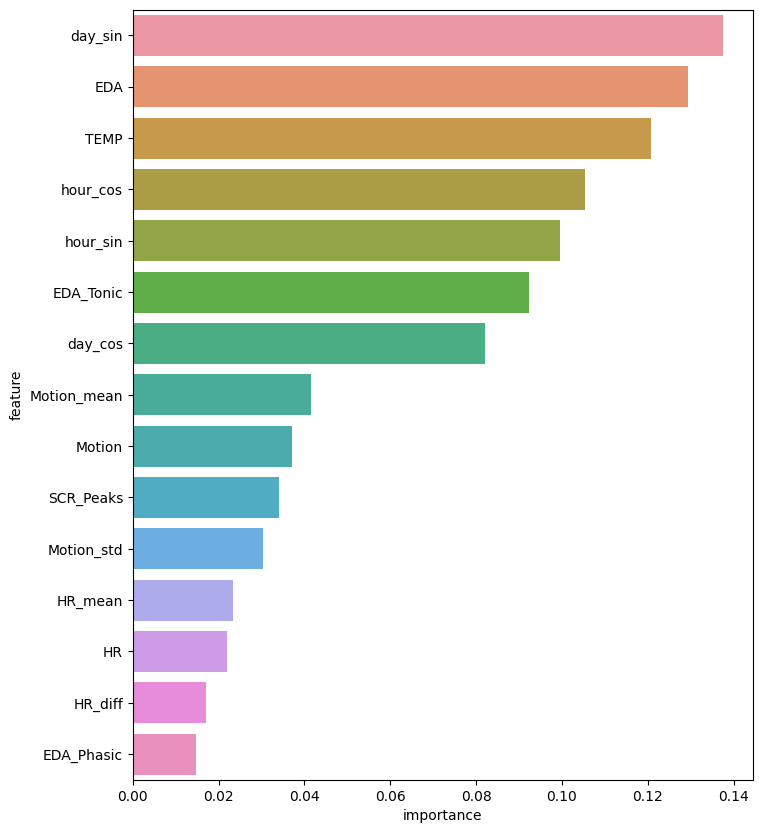

In [112]:
#feature importance
importances=model.feature_importances_
feature_names=X.columns

fi1=pd.DataFrame({ 'feature':  feature_names, 'importance': importances})
fi1=fi.sort_values('importance', ascending= False)
plt.figure(figsize=(8,10))
sns.barplot(data=fi.head(15), x='importance',y='feature')
plt.show()

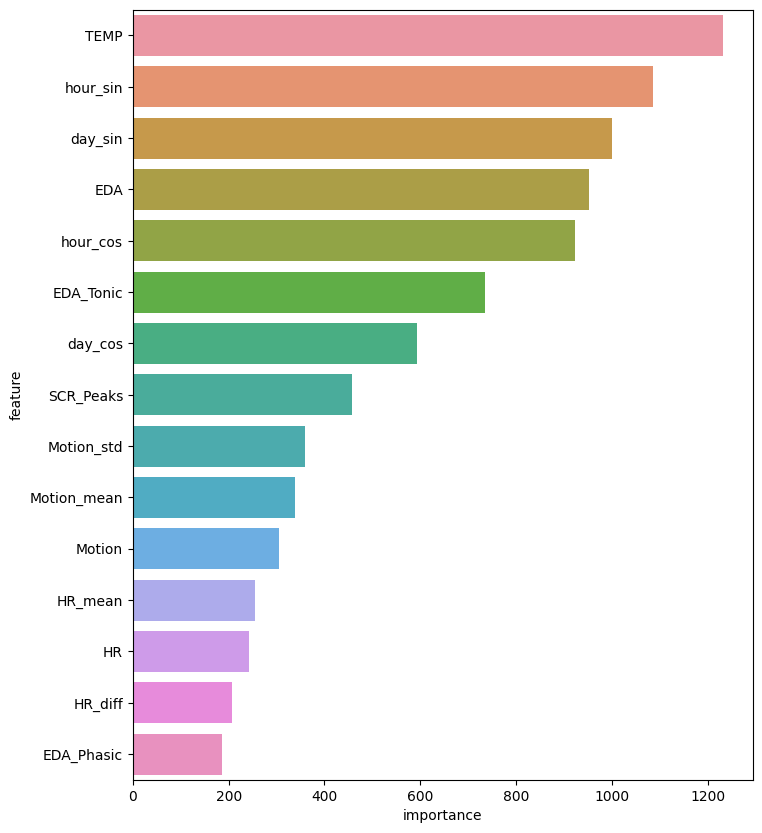

In [113]:
#feature importance
importances=lgb_model.feature_importances_
feature_names=X.columns

fi=pd.DataFrame({ 'feature':  feature_names, 'importance': importances})
fi=fi.sort_values('importance', ascending= False)
plt.figure(figsize=(8,10))
sns.barplot(data=fi.head(15), x='importance',y='feature')
plt.show()